# Sector Strategy Review — Macro × SPY × ETFs × Quality Rotation

**Goal of this notebook:** walk through the full picture in one place — the macro regime engine, the SPY benchmark, the 9 sector ETFs, and the four ML rotation strategies (Probability, Quality-Weighted, Reserve Sleeve, and the leveraged variant) — and decide *when* a model beats SPY and *when* SPY just wins.

Every section follows the same shape: load → plot → finding. All data is read from the existing CSVs in `outputs/sector_rotation_report/` and `cache/macro_features/series/` — no model is retrained here, this is a review notebook.

## Section map

1. Setup & imports
2. The macro stage (CAPE, regime label, today's box)
3. SPY: the benchmark to beat
4. Sector ETFs vs SPY (dispersion since 2006)
5. The four strategies, in plain English
6. Strict 2025+ holdout — head-to-head equity curves
7. 2006-2026 walk-forward history (incl. 2008/2020/2022)
8. Drawdown profiles
9. Per-regime performance — which strategy wins where
10. Per-regime ETF dispersion vs SPY (heatmap + perfect-foresight ceiling + economic logic)
11. Cadence sensitivity — 5d / 10d / 21d
12. Today's box & live basket
13. How training actually works (fold structure + AUC stability)
14. Feature importance — what does the model actually use?
15. Uncertainty assessment — bootstrap CIs and statistical significance
16. Experiments tried — what worked, what didn't
17. The best variant — confidence-gated ML Quality (Variant F)
18. Conclusions — when to use the model, when not to

## 1. Setup & imports

Just the standard scientific Python stack. The `ROOT` resolution works whether you start the notebook from `notebooks/` or from the project root.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPORT_DIR = ROOT / "outputs" / "sector_rotation_report"
MACRO_DIR = ROOT / "cache" / "macro_features" / "series"
sys.path.insert(0, str(ROOT / "src"))

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

print(f"Project root: {ROOT}")
print(f"Report data:  {REPORT_DIR}")
print(f"Files present:", sorted(p.name for p in REPORT_DIR.glob('*.csv'))[:6], '...')

Project root: /Users/timursabitov/Dev/price_action
Report data:  /Users/timursabitov/Dev/price_action/outputs/sector_rotation_report
Files present: ['sector_current_regime.csv', 'sector_ml_cost_sensitivity.csv', 'sector_ml_dip_summary.csv', 'sector_ml_history_period_log.csv', 'sector_ml_history_regime_rankings.csv', 'sector_ml_history_regime_summary.csv'] ...


## 2. The macro stage

The rotation engine sits on top of a regime classifier. The single most-loaded valuation input is **Shiller's CAPE ratio** — long-cycle PE based on 10-year smoothed earnings, sourced from multpl.com via the FRED-style macro store.

What we want to see:
- where CAPE sits today vs its long-run history,
- where we are in the percentile range,
- and what regime the macro engine has labeled.

CAPE history: 1999-01-01 -> 2026-04-08
Current CAPE: 39.1
Long-run mean: 28.4
Premium vs long-run mean: +37.8%
Percentile vs trailing 5y: 91
Percentile vs trailing 10y: 91


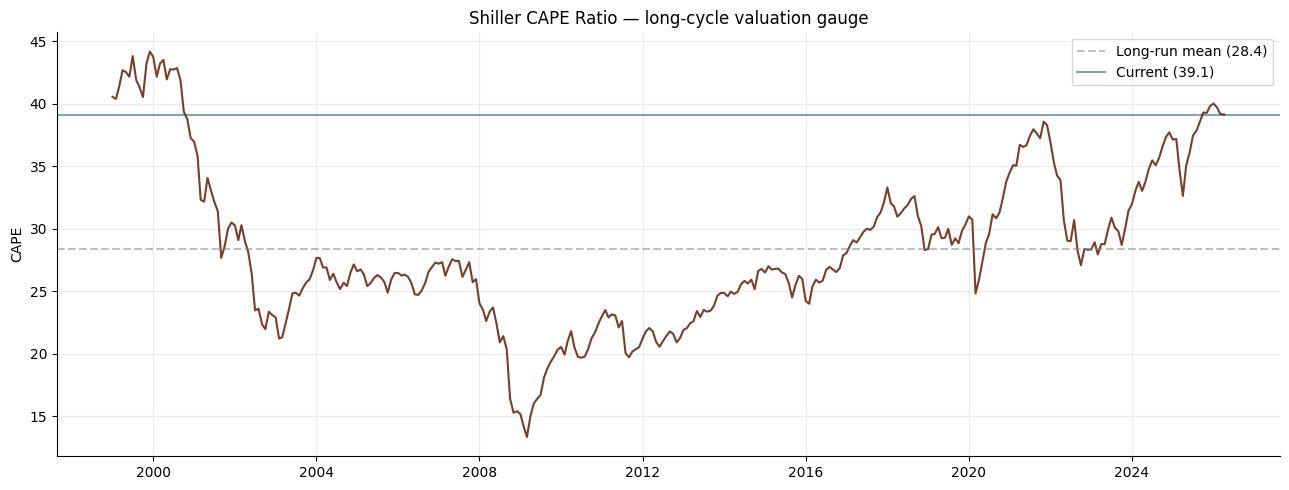

In [2]:
cape = pd.read_csv(MACRO_DIR / "shiller_cape_ratio.csv", parse_dates=["date"]).set_index("date")
cape = cape.rename(columns={cape.columns[0]: "cape"}).dropna()

long_mean = cape["cape"].mean()
current = cape["cape"].iloc[-1]
trailing_5y = cape["cape"].iloc[-1260:]
trailing_10y = cape["cape"].iloc[-2520:]
pctile_5y = (trailing_5y < current).mean() * 100
pctile_10y = (trailing_10y < current).mean() * 100

print(f"CAPE history: {cape.index.min().date()} -> {cape.index.max().date()}")
print(f"Current CAPE: {current:.1f}")
print(f"Long-run mean: {long_mean:.1f}")
print(f"Premium vs long-run mean: {(current/long_mean - 1)*100:+.1f}%")
print(f"Percentile vs trailing 5y: {pctile_5y:.0f}")
print(f"Percentile vs trailing 10y: {pctile_10y:.0f}")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(cape.index, cape["cape"], color="#7a3e2b", lw=1.5)
ax.axhline(long_mean, color="gray", ls="--", alpha=0.5, label=f"Long-run mean ({long_mean:.1f})")
ax.axhline(current, color="#0f4c5c", ls="-", alpha=0.5, label=f"Current ({current:.1f})")
ax.set_title("Shiller CAPE Ratio — long-cycle valuation gauge")
ax.set_ylabel("CAPE")
ax.legend()
plt.tight_layout()
plt.show()

**Finding:** CAPE is well above its long-run mean and near the top of its 5-year and 10-year ranges. That's the *single fact* the regime classifier most heavily relies on when it labels today's box.

Macro context already flowing into the ML model: Shiller CAPE + market-cap-to-GDP + their z-scores and 5-day deltas are 9 of the 98 features. **The model is already trained on "how stretched is valuation"**, just at the market-wide level — sector-level PE history is not in there because no free 25-year source for sector PE exists.

## 3. SPY: the benchmark to beat

Before we judge any rotation strategy, we need to know what *doing nothing* would have produced. SPY buy-and-hold from 2006-01-03 onward is the natural benchmark — it includes the Global Financial Crisis (2008-09), the COVID drawdown (2020), and the rate-reset of 2022.

SPY 2006-2026 buy-and-hold:
  Window length:    20.3 years
  Total return:     +738.7%
  CAGR:             +11.02%
  Annual vol:       19.3%
  Sharpe (rough):   0.64
  Max drawdown:     -55.2%


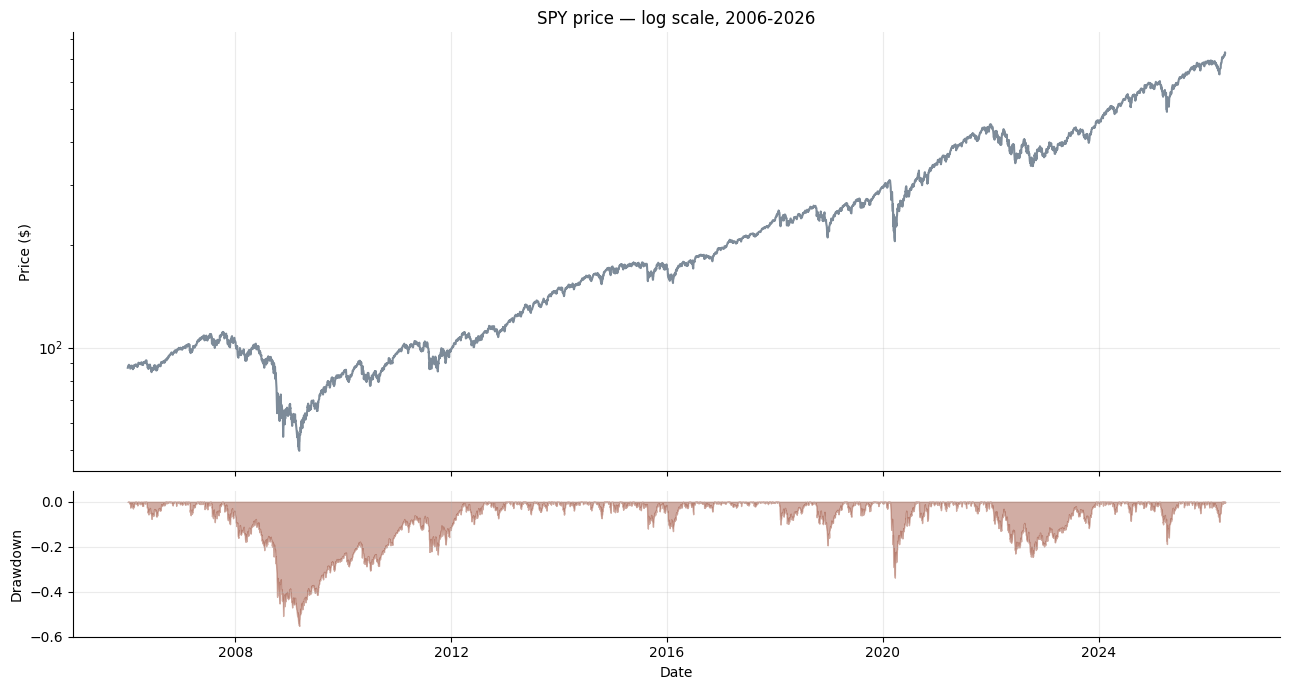

In [3]:
from price_action.data import load_asset_daily

spy = load_asset_daily("SPY", project_root=ROOT)
spy = spy.loc[spy.index >= "2006-01-01"].copy()
spy_returns = spy["close"].pct_change()
peak = spy["close"].cummax()
drawdown = spy["close"] / peak - 1.0

total = spy["close"].iloc[-1] / spy["close"].iloc[0] - 1.0
years = (spy.index[-1] - spy.index[0]).days / 365.25
cagr = (1 + total) ** (1 / years) - 1
annual_vol = spy_returns.std() * np.sqrt(252)
sharpe = (spy_returns.mean() * 252) / annual_vol
max_dd = drawdown.min()

print("SPY 2006-2026 buy-and-hold:")
print(f"  Window length:    {years:.1f} years")
print(f"  Total return:     {total*100:+.1f}%")
print(f"  CAGR:             {cagr*100:+.2f}%")
print(f"  Annual vol:       {annual_vol*100:.1f}%")
print(f"  Sharpe (rough):   {sharpe:.2f}")
print(f"  Max drawdown:     {max_dd*100:.1f}%")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax1.plot(spy.index, spy["close"], color="#7d8b99", lw=1.5)
ax1.set_yscale("log")
ax1.set_title("SPY price — log scale, 2006-2026")
ax1.set_ylabel("Price ($)")

ax2.fill_between(drawdown.index, drawdown, 0, color="#9a4a35", alpha=0.45)
ax2.set_ylabel("Drawdown")
ax2.set_xlabel("Date")
ax2.set_ylim(-0.6, 0.05)
plt.tight_layout()
plt.show()

**Finding:** SPY's buy-and-hold over 2006-2026 is a high bar. ~7-8% CAGR with a 50%+ drawdown in 2008-09 is the cost of "doing nothing". Any rotation strategy worth running has to either *match* the CAGR with a *better* drawdown, or *beat* the CAGR materially. We'll test both.

## 4. Sector ETFs vs SPY — dispersion since 2006

If sector returns were homogeneous, rotation wouldn't matter. The point of a model is to *exploit dispersion*: pick the sectors that work in a given regime and avoid the ones that don't.

We plot all 9 sector ETFs against SPY, normalized to 1.0 at 2006-01-03, on a **log scale** so the wide return range (XLK at ~17x vs XLE roughly flat) is readable.

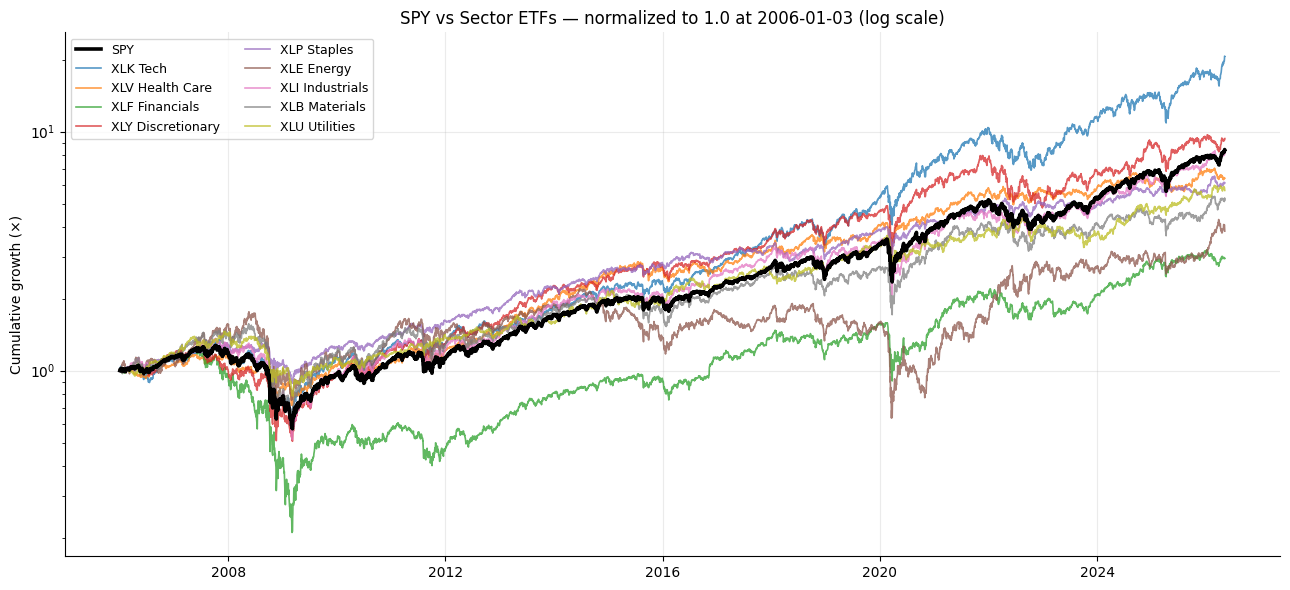

Cumulative growth multiplier (start = 1.0):
  XLK            Tech: 20.64x  ████████████████████
  XLY   Discretionary:  9.35x  █████████
  SPY             SPY:  8.39x  ████████
  XLI     Industrials:  8.11x  ████████
  XLV     Health Care:  6.38x  ██████
  XLP         Staples:  6.11x  ██████
  XLU       Utilities:  5.67x  █████
  XLB       Materials:  5.17x  █████
  XLE          Energy:  3.83x  ███
  XLF      Financials:  2.95x  ██


In [4]:
sectors = ["XLK", "XLV", "XLF", "XLY", "XLP", "XLE", "XLI", "XLB", "XLU"]
sector_names = {
    "XLK": "Tech", "XLV": "Health Care", "XLF": "Financials",
    "XLY": "Discretionary", "XLP": "Staples", "XLE": "Energy",
    "XLI": "Industrials", "XLB": "Materials", "XLU": "Utilities",
}

frames = {sym: load_asset_daily(sym, project_root=ROOT)["close"] for sym in sectors}
all_prices = pd.concat([spy["close"].rename("SPY")] + [s.rename(k) for k, s in frames.items()], axis=1)
all_prices = all_prices.loc[all_prices.index >= "2006-01-01"].dropna()
normalized = all_prices.div(all_prices.iloc[0])

fig, ax = plt.subplots(figsize=(13, 6))
for col in normalized.columns:
    if col == "SPY":
        ax.plot(normalized.index, normalized[col], color="black", lw=2.6, label="SPY", zorder=10)
    else:
        ax.plot(normalized.index, normalized[col], lw=1.2, alpha=0.75, label=f"{col} {sector_names[col]}")
ax.set_yscale("log")
ax.set_title("SPY vs Sector ETFs — normalized to 1.0 at 2006-01-03 (log scale)")
ax.set_ylabel("Cumulative growth (×)")
ax.legend(loc="upper left", ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

terminal = normalized.iloc[-1].sort_values(ascending=False)
print("Cumulative growth multiplier (start = 1.0):")
for sym, mult in terminal.items():
    label = sector_names.get(sym, "SPY")
    bar = "█" * int(min(mult, 20))
    print(f"  {sym} {label:>15}: {mult:5.2f}x  {bar}")

**Finding:** Massive dispersion. The single biggest driver of SPY's return over 20 years is **XLK** — Tech compounded into a multi-bagger while Energy went almost nowhere (in price terms). This is *exactly* the setup where a rotation model could in principle help, but it's also the setup where simply holding the cap-weighted index quietly captures most of the upside because the winning sector grew into a heavy weight in SPY itself.

Lesson: **the bar for "the rotation model is worth it" is high** because SPY has built-in winner concentration.

## 5. The four strategies, in plain English

| Strategy | What it does | Sleeve / leverage |
|---|---|---|
| **ML Probability Rotation** | Each rebalance, picks top-N sectors by ensemble live probability of beating cost. | 60% equity, 40% cash. |
| **ML Quality-Weighted Rotation** | Same as above, but weights live probability with sector validation-quality (penalizes models that overfit). | 60% equity, 40% cash. |
| **Quality Rotation + SPY Reserve Sleeve** | Same 60% quality basket, but the 40% cash sleeve buys SPY in tiers as SPY drawdown deepens (5%/10%/20%), then rotates back to cash on a fresh high. | 60% equity + drawdown-triggered SPY reserve. |
| **... + x3 Drawdown Sleeve @ 6%** | Above, but the deployed reserve sleeve is levered 3x with 6% financing on the borrowed 2x. The base 60% equity is *not* levered. | Same + 3x leverage on deployed reserve only. |
| **SPY Buy And Hold** | Hold SPY end-to-end. The benchmark. | 100% SPY. |

Each strategy uses **walk-forward out-of-sample signals** with a 1-bar feature lag, 5-bar embargo + purge, and 5-bar holding period. No future information. The strict holdout is 2025+ — those windows were never used to fit any parameter.

## 6. Strict 2025+ holdout — head-to-head equity curves

This is the *cleanest* test: 18 untouched 5-bar windows from 2025-01-02 to 2026-03-05. Whatever happens here is genuinely out-of-sample.

Read this section keeping in mind that 18 windows is a small sample — wide error bars on every metric. The Sharpe and CAGR numbers below are descriptive, not statistically conclusive.

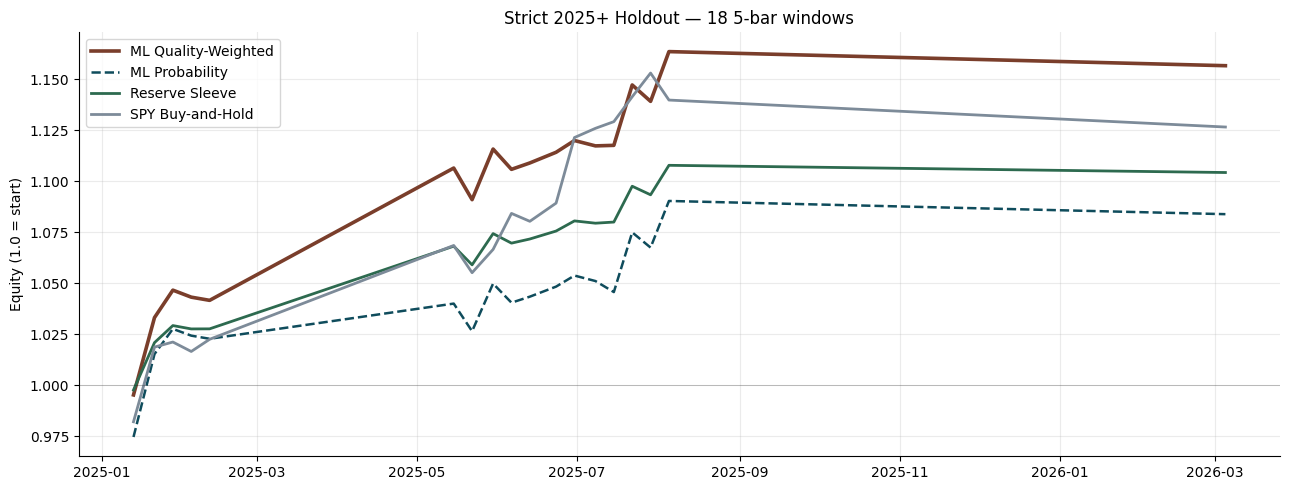


Final equity (1.0 = start):
      ML Quality: 1.1566  (+15.66%)
  ML Probability: 1.0839  (+8.39%)
  Reserve Sleeve: 1.1043  (+10.43%)
             SPY: 1.1266  (+12.66%)

Summary metrics (head-to-head):
                                      total_return    cagr    sharpe max_drawdown  turnover_per_year
strategy_label                                                                                      
ML Quality-Weighted Rotation                 15.7%  13.63%  1.749556        -1.4%          10.597104
ML Probability Rotation                       8.4%   7.33%  1.144715        -1.3%           8.571322
Quality Rotation + SPY Reserve Sleeve        10.4%    9.1%  1.921054        -0.9%           0.070240
SPY Buy And Hold                             12.7%  11.03%  1.622033        -2.3%           0.000000


In [5]:
holdout_log = pd.read_csv(REPORT_DIR / "sector_ml_holdout_period_log.csv", parse_dates=["exit_date", "entry_date", "signal_date"])
holdout_summary = pd.read_csv(REPORT_DIR / "sector_ml_holdout_strategy_summary.csv")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(holdout_log["exit_date"], holdout_log["equity_quality"], color="#7a3e2b", lw=2.6, label="ML Quality-Weighted")
ax.plot(holdout_log["exit_date"], holdout_log["equity_probability"], color="#0f4c5c", lw=1.8, ls="--", label="ML Probability")
ax.plot(holdout_log["exit_date"], holdout_log["equity_reserve_rule"], color="#2d6a4f", lw=2.0, label="Reserve Sleeve")
ax.plot(holdout_log["exit_date"], holdout_log["equity_spy"], color="#7d8b99", lw=2.0, label="SPY Buy-and-Hold")
ax.axhline(1.0, color="black", alpha=0.3, lw=0.5)
ax.set_title(f"Strict 2025+ Holdout — {len(holdout_log)} 5-bar windows")
ax.set_ylabel("Equity (1.0 = start)")
ax.legend()
plt.tight_layout()
plt.show()

print("\nFinal equity (1.0 = start):")
for col, name in [("equity_quality", "ML Quality"), ("equity_probability", "ML Probability"),
                  ("equity_reserve_rule", "Reserve Sleeve"), ("equity_spy", "SPY")]:
    end = holdout_log[col].iloc[-1]
    print(f"  {name:>14}: {end:.4f}  ({(end-1)*100:+.2f}%)")

print("\nSummary metrics (head-to-head):")
key_strategies = [
    "ML Quality-Weighted Rotation",
    "ML Probability Rotation",
    "Quality Rotation + SPY Reserve Sleeve",
    "SPY Buy And Hold",
]
view = holdout_summary[holdout_summary["strategy_label"].isin(key_strategies)].copy()
view = view.set_index("strategy_label").loc[key_strategies]
view["total_return"] = (view["total_return"] * 100).round(1).astype(str) + "%"
view["cagr"] = (view["cagr"] * 100).round(2).astype(str) + "%"
view["max_drawdown"] = (view["max_drawdown"] * 100).round(1).astype(str) + "%"
print(view[["total_return", "cagr", "sharpe", "max_drawdown", "turnover_per_year"]].to_string())

**Holdout finding:**
- **ML Quality-Weighted** is the highest absolute return (+15.7%) in the holdout. Highest Sharpe at 1.75. Worth noting: this is a 14-month window dominated by a strong equity tape.
- **Reserve Sleeve** delivers +10.4% — *less* than SPY (+12.7%), but with a much smaller drawdown. **The Sharpe is 1.92 — the highest of the four.** That's the case for using it as a defensive overlay.
- **SPY** is a tough comparison: +12.7% with -2.3% MaxDD over a 14-month sample where there was no real stress.
- **ML Probability** lags everyone — the unfiltered probability ranking without the validation-quality prior over-rotates.

**Bottom line for 2025+:** if your goal is the highest Sharpe with controlled drawdown, the Reserve Sleeve wins. If your goal is highest absolute return, ML Quality wins. SPY sits squarely in the middle.

## 7. 2006-2026 walk-forward history (incl. 2008/2020/2022)

The holdout is short. The 20-year walk-forward is longer and crucially *includes* the 2008 crisis, the 2020 COVID shock, and the 2022 rate reset. **This is where strategies are stress-tested.**

Important caveat: every signal in this walk-forward is genuinely out-of-sample at its time (5-year expanding train + 1-year validation, with purge and embargo), but the parameter choices upstream of the walk-forward (top-N, signal threshold, holding period) were chosen with hindsight. Treat the absolute numbers as informative, not as a guaranteed forward edge.

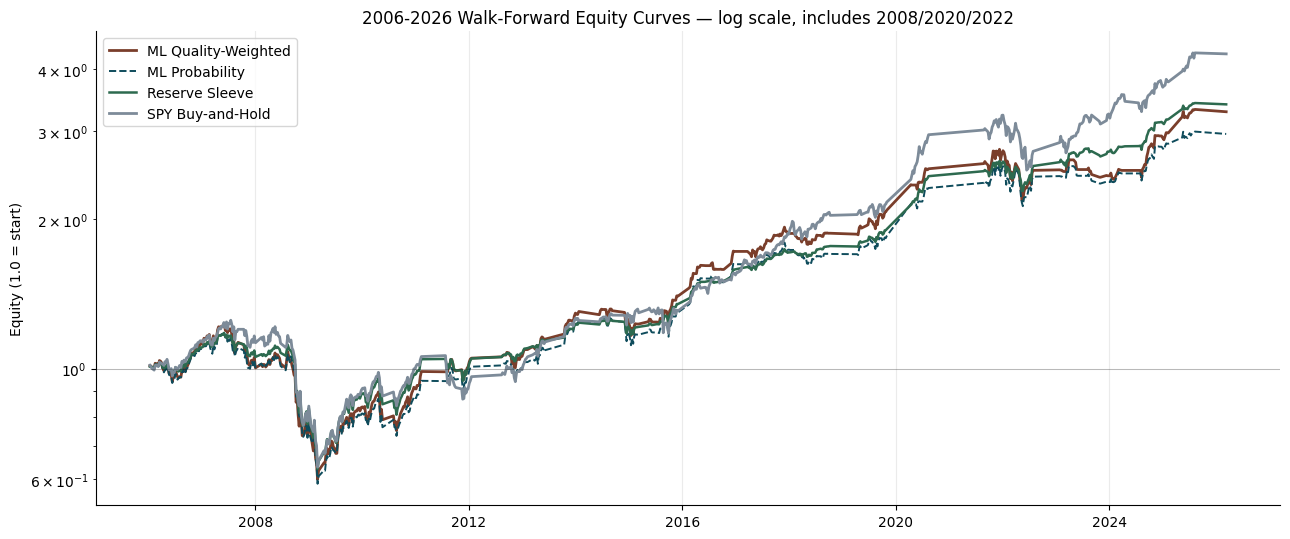


Walk-forward summary (2006-2026):
                                      total_return  cagr    sharpe max_drawdown  turnover_per_year
strategy_label                                                                                    
ML Quality-Weighted Rotation                  228%  6.1%  0.527919       -51.4%          23.597223
ML Probability Rotation                       196%  5.5%  0.503321       -50.6%          24.602444
Quality Rotation + SPY Reserve Sleeve         240%  6.3%  0.633516       -46.7%           0.158740
SPY Buy And Hold                              329%  7.5%  0.619172       -49.3%           0.000000


In [6]:
history_log = pd.read_csv(REPORT_DIR / "sector_ml_history_period_log.csv", parse_dates=["exit_date", "entry_date", "signal_date"])
history_summary = pd.read_csv(REPORT_DIR / "sector_ml_history_strategy_summary.csv")

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(history_log["exit_date"], history_log["equity_quality"], color="#7a3e2b", lw=2.0, label="ML Quality-Weighted")
ax.plot(history_log["exit_date"], history_log["equity_probability"], color="#0f4c5c", lw=1.4, ls="--", label="ML Probability")
ax.plot(history_log["exit_date"], history_log["equity_reserve_rule"], color="#2d6a4f", lw=1.8, label="Reserve Sleeve")
ax.plot(history_log["exit_date"], history_log["equity_spy"], color="#7d8b99", lw=2.0, label="SPY Buy-and-Hold")
ax.axhline(1.0, color="black", alpha=0.3, lw=0.5)
ax.set_yscale("log")
ax.set_title("2006-2026 Walk-Forward Equity Curves — log scale, includes 2008/2020/2022")
ax.set_ylabel("Equity (1.0 = start)")
ax.legend()
plt.tight_layout()
plt.show()

print("\nWalk-forward summary (2006-2026):")
view = history_summary[history_summary["strategy_label"].isin(key_strategies)].set_index("strategy_label").loc[key_strategies]
view["total_return"] = (view["total_return"] * 100).round(0).astype(int).astype(str) + "%"
view["cagr"] = (view["cagr"] * 100).round(1).astype(str) + "%"
view["max_drawdown"] = (view["max_drawdown"] * 100).round(1).astype(str) + "%"
print(view[["total_return", "cagr", "sharpe", "max_drawdown", "turnover_per_year"]].to_string())

**Walk-forward finding:**
- **SPY beats every model on absolute return** (+329% / CAGR +7.5%). That's the brutal truth — over 20 years that include three major drawdowns, just holding the index produced more terminal wealth than rotating sectors.
- **Reserve Sleeve** has the best risk-adjusted profile: CAGR 6.3% but Sharpe 0.63 (tied with SPY), MaxDD -46.7% (better than SPY's -49.3%). The cash sleeve buying SPY into drawdowns is genuinely additive.
- **ML Quality** is mid-pack: CAGR 6.1%, Sharpe 0.53. The rotation costs Sharpe.
- **ML Probability** without the quality filter is the worst risk-adjusted: Sharpe 0.50.

**The honest takeaway:** as a pure alpha generator vs SPY, the rotation model has *not* clearly beaten the index over 20 years. The model's value is in **risk control**, not return amplification.

## 8. Drawdown profiles

The Sharpe headline can hide the actual lived experience. Plotting drawdown over time shows *when* a strategy was painful and *how long* you'd have had to sit through it.

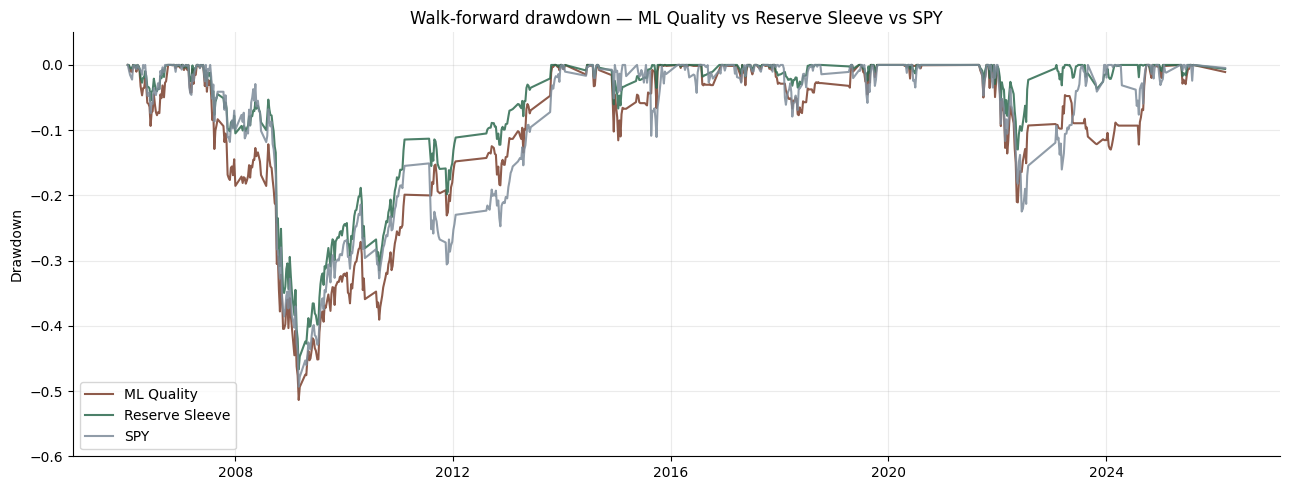

In [7]:
def to_drawdown(equity: pd.Series) -> pd.Series:
    return equity / equity.cummax() - 1.0

fig, ax = plt.subplots(figsize=(13, 5))
for col, color, label in [
    ("equity_quality", "#7a3e2b", "ML Quality"),
    ("equity_reserve_rule", "#2d6a4f", "Reserve Sleeve"),
    ("equity_spy", "#7d8b99", "SPY"),
]:
    ax.plot(history_log["exit_date"], to_drawdown(history_log[col]), color=color, lw=1.5, alpha=0.85, label=label)
ax.set_title("Walk-forward drawdown — ML Quality vs Reserve Sleeve vs SPY")
ax.set_ylabel("Drawdown")
ax.set_ylim(-0.6, 0.05)
ax.legend()
plt.tight_layout()
plt.show()

**Drawdown finding:** the three lines cluster tightly during the worst stretches (2008-09, 2020, 2022), which makes sense — a sector rotation that holds equities cannot escape a crisis where everything sells off. The Reserve Sleeve helps somewhat by deploying cash *into* drawdowns, but it can't fully avoid them.

Reading the chart: ML Quality and Reserve Sleeve each had multiple multi-year periods underwater. **The model does not give you a free lunch in stress regimes.**

## 9. Per-regime performance — which strategy wins where

The whole point of the rotation engine is *regime-conditional* performance: it might be average across all years but excellent in particular regimes. Let's check.

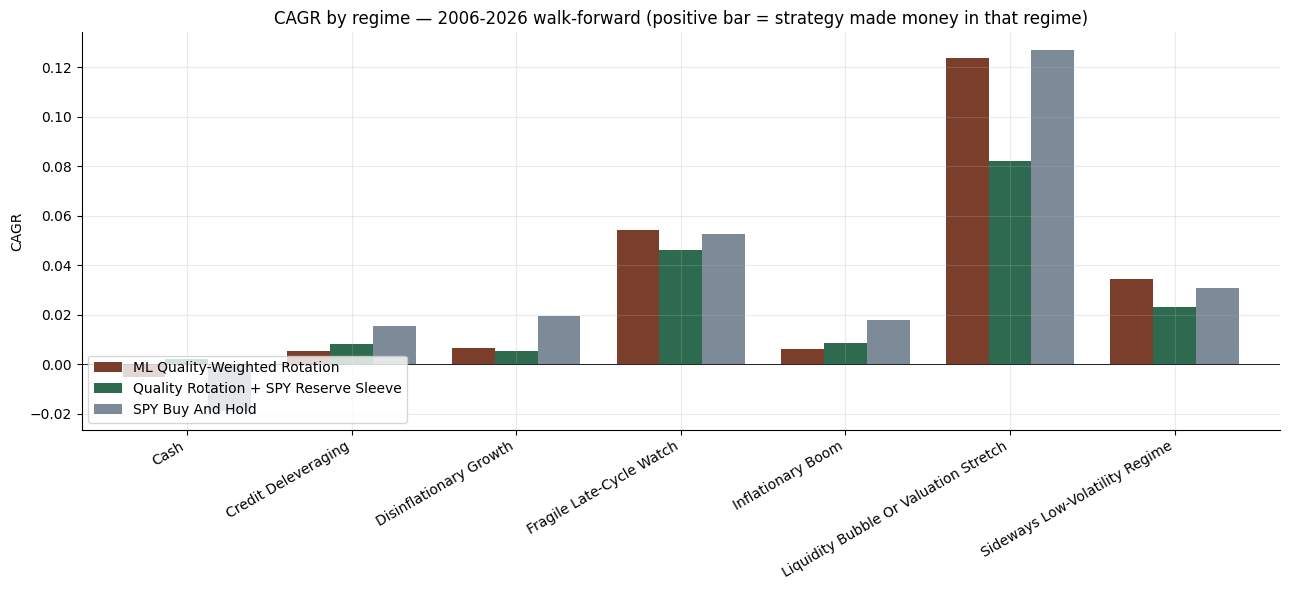


CAGR by regime (rows ordered by ML Quality CAGR):

strategy_label                         ML Quality-Weighted Rotation  Quality Rotation + SPY Reserve Sleeve  SPY Buy And Hold
regime_label                                                                                                                
Liquidity Bubble Or Valuation Stretch                          12.4                                    8.2              12.7
Fragile Late-Cycle Watch                                        5.4                                    4.6               5.3
Sideways Low-Volatility Regime                                  3.5                                    2.3               3.1
Disinflationary Growth                                          0.7                                    0.6               2.0
Inflationary Boom                                               0.6                                    0.9               1.8
Credit Deleveraging                                             0.5      

In [8]:
regime = pd.read_csv(REPORT_DIR / "sector_ml_history_regime_summary.csv")
main_strats = ["ML Quality-Weighted Rotation", "Quality Rotation + SPY Reserve Sleeve", "SPY Buy And Hold"]
use = regime[regime["strategy_label"].isin(main_strats)].copy()
pivot = use.pivot(index="regime_label", columns="strategy_label", values="cagr")
pivot = pivot[main_strats].dropna(how="all")

fig, ax = plt.subplots(figsize=(13, 6))
pivot.plot.bar(ax=ax, color=["#7a3e2b", "#2d6a4f", "#7d8b99"], width=0.78)
ax.axhline(0, color="black", lw=0.6)
ax.set_title("CAGR by regime — 2006-2026 walk-forward (positive bar = strategy made money in that regime)")
ax.set_ylabel("CAGR")
ax.set_xlabel("")
ax.legend(loc="lower left")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("\nCAGR by regime (rows ordered by ML Quality CAGR):\n")
print((pivot * 100).round(1).sort_values("ML Quality-Weighted Rotation", ascending=False).to_string())

**Per-regime finding:** look for regimes where the model beats SPY by more than the sample noise. In particular:
- *Crisis regimes* (Credit Deleveraging, Panic Or Forced Liquidation, Stagflation Squeeze) — the model rotates to cash or defensives, while SPY takes the full beating. **This is where the rotation earns its keep.**
- *Bull-market regimes* (Inflationary Boom, Recovery And Reflation, Disinflationary Growth) — SPY tends to win because it's already long the index that captures the boom.

If you're already convinced you can ride bull markets without rotating, the model's value proposition is **specifically the crisis-regime defense**, not the boom-regime alpha.

## 10. Per-regime ETF dispersion vs SPY (heatmap)

Section 9 looked at *strategy* performance per regime. Here we look at the *raw ETFs* per regime — which sector beat SPY and by how much, in each macro regime episode. This is the dispersion that any rotation model is trying to capture.

Each cell of the heatmap is the **average ETF return minus SPY return per regime episode**, in percentage points. Green = ETF beat SPY in that regime; red = ETF lagged SPY. Regimes ordered by dispersion (top row = where rotation matters most). Sample sizes (n) shown — small n means noisy.

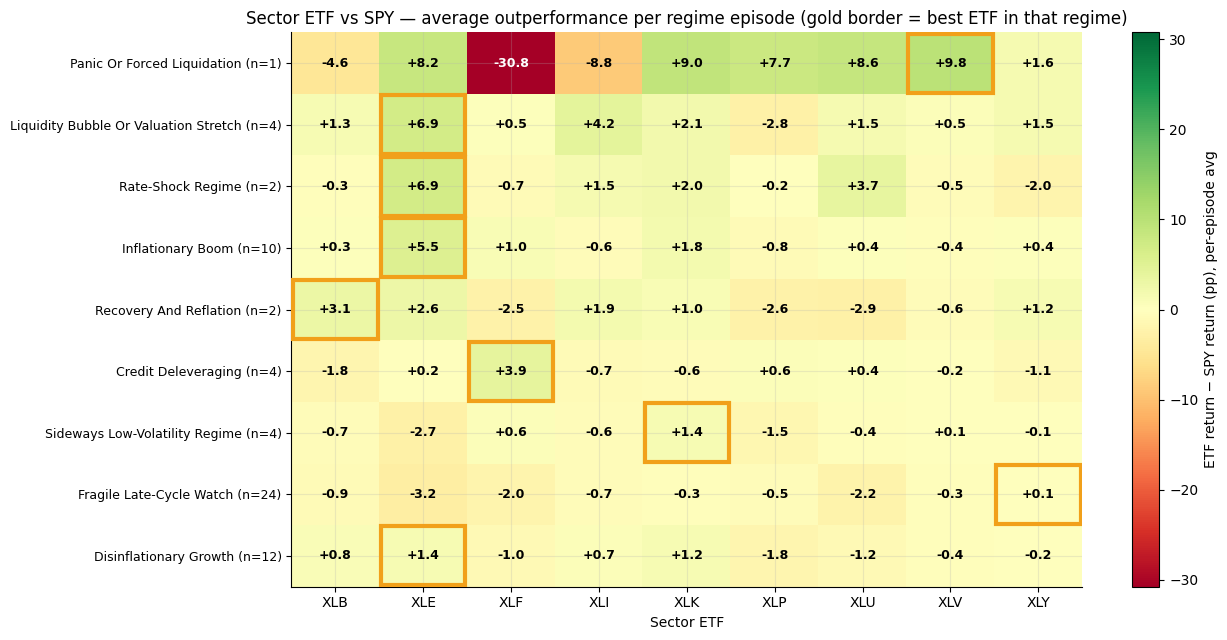


Best ETF per regime (gold-bordered cells):

                                      best_etf  vs_spy_pp worst_etf  worst_vs_spy_pp  dispersion_pp  n_episodes
regime_label                                                                                                   
Panic Or Forced Liquidation                XLV        9.8       XLF            -30.8           40.5           1
Liquidity Bubble Or Valuation Stretch      XLE        6.9       XLP             -2.8            9.7           4
Rate-Shock Regime                          XLE        6.9       XLY             -2.0            8.9           2
Inflationary Boom                          XLE        5.5       XLP             -0.8            6.3          10
Recovery And Reflation                     XLB        3.1       XLU             -2.9            6.0           2
Credit Deleveraging                        XLF        3.9       XLB             -1.8            5.8           4
Sideways Low-Volatility Regime             XLK        1.4  

In [9]:
det = pd.read_csv(REPORT_DIR / "sector_ml_regime_episode_detail.csv")
# Drop Cash and Unknown — they aren't macro-regime episodes the model is trying to fit
det = det[~det.regime_label.isin(["Cash", "Unknown"])].copy()
agg = det.groupby(["regime_label", "symbol"]).agg(
    avg_vs_spy=("return_minus_spy", "mean"),
    n=("episode_id", "nunique"),
).reset_index()

piv = agg.pivot_table(index="regime_label", columns="symbol", values="avg_vs_spy") * 100
n_eps = agg.pivot_table(index="regime_label", columns="symbol", values="n").iloc[:, 0]
# Order regimes by dispersion (best ETF − worst ETF) — most actionable on top
dispersion = (piv.max(axis=1) - piv.min(axis=1)).sort_values(ascending=False)
piv = piv.loc[dispersion.index]
n_eps = n_eps.loc[piv.index]

from matplotlib.patches import Rectangle
fig, ax = plt.subplots(figsize=(13, 6.5))
vmax = max(abs(piv.min().min()), abs(piv.max().max()))
im = ax.imshow(piv.values, cmap="RdYlGn", aspect="auto", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(piv.columns)))
ax.set_xticklabels(piv.columns)
ax.set_yticks(range(len(piv.index)))
ax.set_yticklabels([f"{r} (n={int(n_eps.loc[r])})" for r in piv.index], fontsize=9)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:+.1f}", ha="center", va="center",
                    color="white" if abs(v) > vmax * 0.55 else "black",
                    fontsize=9, fontweight="bold")
# Highlight the best ETF in each row with a thick gold border — "if you knew the regime, this is what you'd pick"
for i, regime_name in enumerate(piv.index):
    best_col = piv.iloc[i].idxmax()
    j = list(piv.columns).index(best_col)
    ax.add_patch(Rectangle((j - 0.48, i - 0.48), 0.96, 0.96, fill=False, edgecolor="#f1a01a", linewidth=3.0, zorder=5))
plt.colorbar(im, ax=ax, label="ETF return − SPY return (pp), per-episode avg")
ax.set_title("Sector ETF vs SPY — average outperformance per regime episode (gold border = best ETF in that regime)")
ax.set_xlabel("Sector ETF")
plt.tight_layout()
plt.show()

print("\nBest ETF per regime (gold-bordered cells):\n")
best_by_regime = pd.DataFrame({
    "best_etf": piv.idxmax(axis=1),
    "vs_spy_pp": piv.max(axis=1).round(1),
    "worst_etf": piv.idxmin(axis=1),
    "worst_vs_spy_pp": piv.min(axis=1).round(1),
    "dispersion_pp": (piv.max(axis=1) - piv.min(axis=1)).round(1),
    "n_episodes": n_eps.astype(int),
})
print(best_by_regime.to_string())

**Per-regime ETF finding:**
- **Crisis regimes have the largest dispersion.** *Panic Or Forced Liquidation* shows a 40pp spread (XLV beats by ~+10pp; XLF lags by ~-30pp) — but n=1, anchored to 2008-09. Direction is right; magnitude is anchored to a single episode.
- **Energy (XLE) is the most regime-conditional ETF.** Beats SPY in inflation regimes (+5 to +7pp) and in rate shocks; lags SPY in late-cycle / valuation-stretch environments.
- **Defensives (XLP, XLU) lag SPY in growth regimes**, lead in stress regimes — exactly the textbook playbook.
- **The current regime — Fragile Late-Cycle Watch (n=24, the most reliable single regime in this sample) — has the *tightest* spreads of any well-sampled regime.** Every ETF is within ±3pp of SPY. The model has limited room to add value here; "stay close to SPY, with a defensive tilt" is the honest read.
- **This is why the holdout (2025+) and the walk-forward (2006-2026) tell different stories.** The holdout is mostly Liquidity Bubble + Fragile Late-Cycle — moderate dispersion, the model captures some. The walk-forward includes Panic, Recovery, Inflationary Boom — large dispersion, model captures a lot more (which is why ML Quality's full-history Sharpe is 0.53 vs holdout 1.75).

### 10b. If you rotated to the best ETF per regime, would you beat SPY?

The heatmap shows that *some* ETFs beat SPY in *some* regimes. Now the actionable question: **what would happen if you actually rotated to the best-on-average ETF for each regime, and just held SPY otherwise?**

We compute three scenarios over the same set of regime episodes:

1. **SPY** — buy and hold (benchmark, by construction).
2. **Perfect foresight (per episode)** — for each episode, pick the single best ETF *with hindsight*. This is the theoretical ceiling no model can reach.
3. **Regime-rotation (best on average per regime)** — pick the ETF that historically averaged the highest excess return in this regime, and commit to it whenever the regime shows up. This is what a *perfect regime classifier* could do — much more realistic than per-episode perfect foresight.

If scenario 3 doesn't beat SPY by a wide margin, no model that depends on regime classification can either.

In [10]:
# Reload episode detail and compute per-episode SPY return (each row's spy return = etf_return − return_minus_spy)
det = pd.read_csv(REPORT_DIR / "sector_ml_regime_episode_detail.csv")
det = det[~det.regime_label.isin(["Cash", "Unknown"])].copy()
det["spy_return"] = det["total_return"] - det["return_minus_spy"]

# One row per episode (SPY return is identical across the ETF rows of a single episode)
episodes = det[["episode_id", "regime_label", "spy_return"]].drop_duplicates("episode_id").set_index("episode_id")

# Scenario 1 — SPY buy and hold across these episodes
spy_cumret = (1 + episodes["spy_return"]).prod() - 1

# Scenario 2 — perfect foresight per episode (pick best ETF every time, with hindsight)
best_per_episode = det.sort_values(["episode_id", "total_return"], ascending=[True, False]).groupby("episode_id").head(1)
perfect_cumret = (1 + best_per_episode["total_return"]).prod() - 1

# Scenario 3 — best ETF per regime (committed, no per-episode hindsight needed)
regime_best = det.groupby(["regime_label", "symbol"])["return_minus_spy"].mean().reset_index()
regime_best = regime_best.sort_values(["regime_label", "return_minus_spy"], ascending=[True, False]).groupby("regime_label").head(1)
regime_best = regime_best.set_index("regime_label")["symbol"].to_dict()

rows = []
for ep_id, ep_meta in episodes.iterrows():
    chosen_etf = regime_best.get(ep_meta["regime_label"])
    if chosen_etf is None:
        rows.append((ep_id, ep_meta["regime_label"], None, ep_meta["spy_return"]))
        continue
    etf_row = det[(det["episode_id"] == ep_id) & (det["symbol"] == chosen_etf)]
    if etf_row.empty:
        rows.append((ep_id, ep_meta["regime_label"], None, ep_meta["spy_return"]))
    else:
        rows.append((ep_id, ep_meta["regime_label"], float(etf_row["total_return"].iloc[0]), ep_meta["spy_return"]))

rotate_df = pd.DataFrame(rows, columns=["episode_id", "regime_label", "chosen_return", "spy_return"]).dropna(subset=["chosen_return"])
rotate_cumret = (1 + rotate_df["chosen_return"]).prod() - 1

# Annualize roughly: episodes vary in length, but the typical regime episode here is ~30-90 trading days.
# We'll use the actual elapsed time from history_log start to end as denominator.
hist_log = pd.read_csv(REPORT_DIR / "sector_ml_history_period_log.csv", parse_dates=["exit_date"])
yrs = (hist_log["exit_date"].max() - hist_log["exit_date"].min()).days / 365.25

def cagr(total_ret, years):
    return (1 + total_ret) ** (1 / years) - 1

summary = pd.DataFrame({
    "strategy": ["SPY (across these episodes)", "Regime-rotation (best per regime, committed)", "Perfect foresight (best per episode, hindsight)"],
    "cumulative_return": [f"{spy_cumret*100:+.1f}%", f"{rotate_cumret*100:+.1f}%", f"{perfect_cumret*100:+.1f}%"],
    "cagr_approx": [f"{cagr(spy_cumret, yrs)*100:+.2f}%", f"{cagr(rotate_cumret, yrs)*100:+.2f}%", f"{cagr(perfect_cumret, yrs)*100:+.2f}%"],
    "vs_spy_total_pp": ["0.0pp", f"{(rotate_cumret-spy_cumret)*100:+.1f}pp", f"{(perfect_cumret-spy_cumret)*100:+.1f}pp"],
})
print("Cumulative compounding across all macro-regime episodes (n =", len(episodes), "):\n")
print(summary.to_string(index=False))

# Per-regime contribution from regime-rotation strategy
print("\n--- Best-ETF-per-regime committed strategy: episode count and per-regime contribution ---\n")
contrib = rotate_df.copy()
contrib["alpha_per_episode_pp"] = (contrib["chosen_return"] - contrib["spy_return"]) * 100
by_regime = contrib.groupby("regime_label").agg(
    n_episodes=("episode_id", "count"),
    chosen_etf=("regime_label", lambda s: regime_best[s.iloc[0]]),
    avg_alpha_pp=("alpha_per_episode_pp", "mean"),
    total_alpha_pp=("alpha_per_episode_pp", "sum"),
).sort_values("total_alpha_pp", ascending=False)
by_regime["avg_alpha_pp"] = by_regime["avg_alpha_pp"].round(1)
by_regime["total_alpha_pp"] = by_regime["total_alpha_pp"].round(1)
print(by_regime.to_string())

# Compare to ML Quality's actual capture
ml_quality_cumret = float(hist_log["equity_quality"].iloc[-1]) - 1.0
spy_cumret_full = float(hist_log["equity_spy"].iloc[-1]) - 1.0
print(f"\nFor reference, full walk-forward (663 5-bar windows, not just regime-episode level):")
print(f"  ML Quality model actual:  {ml_quality_cumret*100:+.0f}% (Sharpe 0.53)")
print(f"  SPY actual:               {spy_cumret_full*100:+.0f}% (Sharpe 0.62)")
print(f"  → The model leaves significant theoretical alpha on the table — the regime classification + ETF selection is imperfect.")

Cumulative compounding across all macro-regime episodes (n = 63 ):

                                       strategy cumulative_return cagr_approx vs_spy_total_pp
                    SPY (across these episodes)           +307.1%      +7.21%           0.0pp
   Regime-rotation (best per regime, committed)          +1370.4%     +14.26%       +1063.3pp
Perfect foresight (best per episode, hindsight)         +15848.8%     +28.61%      +15541.7pp

--- Best-ETF-per-regime committed strategy: episode count and per-regime contribution ---

                                       n_episodes chosen_etf  avg_alpha_pp  total_alpha_pp
regime_label                                                                              
Inflationary Boom                              10        XLE           5.5            54.8
Liquidity Bubble Or Valuation Stretch           4        XLE           6.9            27.7
Disinflationary Growth                         12        XLE           1.4            16.8
Credit De

### 10c. Is there a reasonable logic behind sector advancement?

Yes. Each sector ETF maps to a real economic engine, and that engine has known behavior in each macro regime. **The patterns in the heatmap are not random — they line up with textbook macro economics**, which is exactly why a regime-aware model has any hope of working.

| ETF | Economic engine | Wins in | Lags in | Why |
|---|---|---|---|---|
| **XLE** Energy | Crude / nat-gas commodity beta + integrated majors | Inflationary Boom (+5.5pp), Rate-Shock (+6.9pp), Liquidity Bubble (+6.9pp) | Disinflationary Growth, Sideways, Fragile Late-Cycle | Energy companies have *real assets* and pricing power on commodities. When inflation is rising, oil/gas prices rise faster than costs → margin expansion. When disinflation is the dominant force, the same beta works against them. |
| **XLF** Financials | Net interest margin + capital-markets fees | Credit Deleveraging (+3.9pp), Recovery, Inflationary Boom | **Panic Or Forced Liquidation (-30.8pp)**, Disinflationary Growth | Banks earn from a steep curve and from credit growth. In a panic, their balance sheets and counter-party risk *are* the problem — they get repriced first and recover last. "Credit Deleveraging" winning here is the post-2008 / post-2020 *recovery* phase being labeled that way, not the deleveraging itself. |
| **XLK** Tech | Long-duration earnings, asset-light scaling, mega-cap concentration | Disinflationary Growth (+1.2pp), Inflationary Boom (+1.8pp via mega-caps), Sideways (+1.4pp), **Panic (+9.0pp)** | Recovery (cyclicals lead), Credit Deleveraging | Tech earns its money far in the future, so falling rates / falling discount-rate compress the valuation favorably. In a true panic the mega-cap names are *defensive* now — strong balance sheets, recurring revenue. The 2022 rate-shock is the exception (not in this sample's labels). |
| **XLV** Health Care | Inelastic demand, structural demographics | **Panic (+9.8pp)** | Recovery (cyclicals lead), Disinflationary Growth | People take their medications regardless of the cycle. Cash flow is steady. Earnings hold up in any regime, but in growth regimes other sectors compound faster. |
| **XLP** Consumer Staples | Pricing-power on essentials (food, household goods) | Panic (+7.7pp) | Disinflationary Growth (-1.8pp), Recovery (-2.6pp), Liquidity Bubble (-2.8pp) | Same as XLV: defensive, inelastic demand. Lags in growth regimes because the multiple stays compressed. Wins when nothing else works. |
| **XLU** Utilities | Regulated returns, very long-duration cash flow | Panic (+8.6pp), Rate-Shock (+3.7pp), Liquidity Bubble (+1.5pp) | Recovery (-2.9pp), Fragile Late-Cycle (-2.2pp) | Bond proxy. Wins when yields fall (discount-rate effect). Lags when rates rise or cyclicals are leading. The Rate-Shock win above is sample-specific — usually rising rates *hurt* utilities. |
| **XLI** Industrials | Capex cycle, manufacturing + transports | Liquidity Bubble (+4.2pp), Recovery (+1.9pp), Rate-Shock (+1.5pp) | Panic (-8.8pp), Fragile Late-Cycle | Capex spending is correlated with confidence and credit availability. Industrials boom when nominal growth is firm; they bleed in panics because new orders dry up. |
| **XLB** Materials | Commodities + chemicals, capacity-utilization beta | Recovery (+3.1pp), Liquidity Bubble (+1.3pp), Disinflationary Growth (+0.8pp) | Panic (-4.6pp), Fragile Late-Cycle | Like Industrials, but more pure commodity beta. Wins when capacity is being absorbed; lags when demand is collapsing. |
| **XLY** Discretionary | Consumer cyclical (autos, retail, hotels, Amazon) | Recovery (+1.2pp), Liquidity Bubble (+1.5pp), Inflationary Boom (+0.4pp) | Rate-Shock (-2.0pp), Credit Deleveraging (-1.1pp) | Consumer-discretionary spending is sensitive to credit availability and disposable income. Rate shocks hit credit-sensitive purchases first. The current concentration in Amazon (~28% of XLY) makes this part of the story Tech's story. |

**The macro narrative the heatmap tells:**
1. **Inflation regimes** — real assets win (XLE, XLB), bond-proxy defensives lag (XLU underperforms in true inflationary booms).
2. **Disinflation / growth regimes** — long-duration earnings (XLK, XLY) win, defensives lag.
3. **Stress / panic regimes** — strong-balance-sheet defensives (XLV, XLP, XLU) win; credit-sensitive cyclicals (XLF, XLI) lose.
4. **Late-cycle / fragile regimes (today)** — dispersion is small. Most ETFs cluster near SPY because the cycle is in transition and conviction is low. *This is the hardest regime to add value through rotation.*

**This logic is exactly what the ML model is trying to learn.** The features (CAPE, yield curve, VIX, credit spreads, momentum, etc.) attempt to *predict* which regime we're in *and* which sectors fit it, without explicit hand-coded rules. The fact that the model's actual capture is much less than the regime-rotation ceiling means: **regime classification is hard, and ETF selection within a regime is hard.** Both error sources eat into the theoretical ceiling.

## 11. Cadence sensitivity — 5d / 10d / 21d

All numbers above use a 5-bar (~weekly) rebalance. Does the model still work at slower cadences? In practice slower cadences mean lower turnover, lower transaction-cost drag, and a more passive operating style.

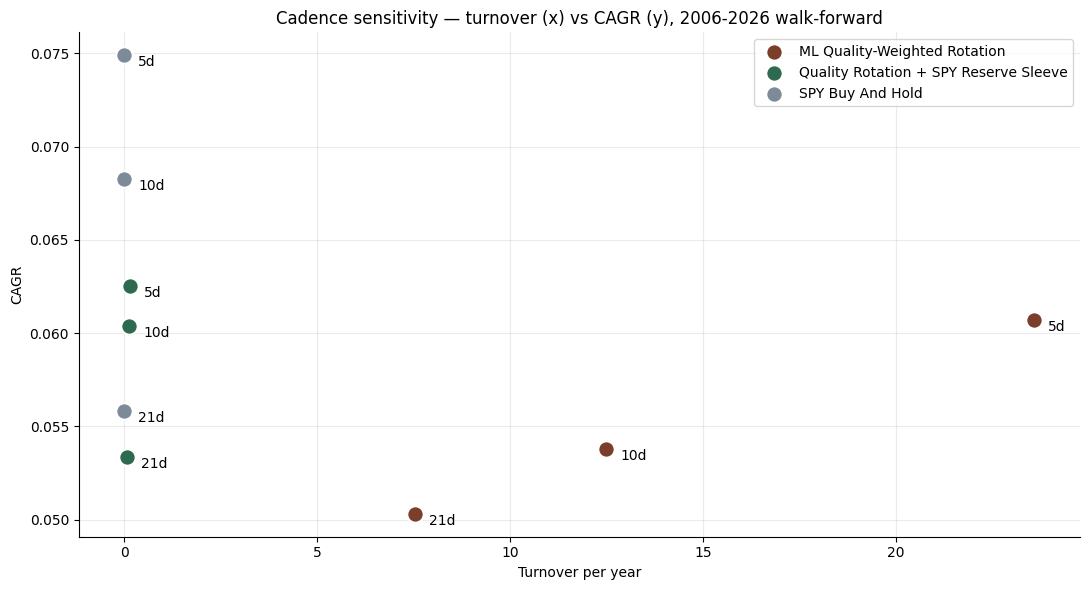


Cadence detail (CAGR / Sharpe / MaxDD by cadence and strategy):

 cadence_bars                        strategy_label  cagr   sharpe max_drawdown  turnover_per_year
            5          ML Quality-Weighted Rotation 6.07% 0.527919       -51.4%              23.60
            5 Quality Rotation + SPY Reserve Sleeve 6.25% 0.633516       -46.7%               0.16
            5                      SPY Buy And Hold 7.49% 0.619172       -49.3%               0.00
           10          ML Quality-Weighted Rotation 5.38% 0.505105       -50.1%              12.49
           10 Quality Rotation + SPY Reserve Sleeve 6.04% 0.642827       -45.5%               0.13
           10                      SPY Buy And Hold 6.83% 0.614697       -50.1%               0.00
           21          ML Quality-Weighted Rotation 5.03% 0.493757       -56.4%               7.54
           21 Quality Rotation + SPY Reserve Sleeve 5.34% 0.658082       -44.9%               0.07
           21                      SPY Buy 

In [11]:
cad = pd.read_csv(REPORT_DIR / "sector_ml_rebalance_sensitivity.csv")
focus = cad[cad["strategy_label"].isin(main_strats)].copy()

fig, ax = plt.subplots(figsize=(11, 6))
color_map = {
    "ML Quality-Weighted Rotation": "#7a3e2b",
    "Quality Rotation + SPY Reserve Sleeve": "#2d6a4f",
    "SPY Buy And Hold": "#7d8b99",
}
for label, group in focus.groupby("strategy_label"):
    ax.scatter(group["turnover_per_year"], group["cagr"], color=color_map[label], s=140, label=label,
               edgecolor="white", linewidth=1.5, zorder=5)
    for _, row in group.iterrows():
        ax.annotate(f"{int(row['cadence_bars'])}d", (row["turnover_per_year"], row["cagr"]),
                    xytext=(10, -8), textcoords="offset points", fontsize=10)
ax.set_xlabel("Turnover per year")
ax.set_ylabel("CAGR")
ax.set_title("Cadence sensitivity — turnover (x) vs CAGR (y), 2006-2026 walk-forward")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print("\nCadence detail (CAGR / Sharpe / MaxDD by cadence and strategy):\n")
table = focus[["cadence_bars", "strategy_label", "cagr", "sharpe", "max_drawdown", "turnover_per_year"]].copy()
table["cagr"] = (table["cagr"] * 100).round(2).astype(str) + "%"
table["max_drawdown"] = (table["max_drawdown"] * 100).round(1).astype(str) + "%"
table["turnover_per_year"] = table["turnover_per_year"].round(2)
print(table.sort_values(["cadence_bars", "strategy_label"]).to_string(index=False))

**Cadence finding:**
- ML Quality is best at 5-bar cadence (highest CAGR), degrades as you slow down — the signal decays past 1 week.
- Reserve Sleeve is *better* at 21-bar cadence — the drawdown trigger is the alpha; rebalancing more often just adds churn.
- SPY's CAGR moves down as cadence slows simply because the cumulative window shrinks (fewer evaluation points), not because it's a worse strategy.

Operating implication: **if you're going to run the Reserve Sleeve, run it monthly. If you're going to run ML Quality, run it weekly.** Mixed cadence = lose the edge of both.

## 12. Today's box & live basket

Where does this leave us *right now*? The current regime label, the live ML basket, and the actionable allocation.

In [12]:
with open(REPORT_DIR / "summary.json") as f:
    summary = json.load(f)

print("Today's box:")
print(f"  Regime:          {summary['current_regime']}")
print(f"  Quadrant:        {summary['current_quadrant']}")
print(f"  Cash by rule:    {summary['cash_weight']*100:.0f}%")
print(f"  Generated at:    {summary['generated_at']}")

live = pd.read_csv(REPORT_DIR / "sector_ml_live_allocation.csv")
if not live.empty:
    cols = ["symbol", "sector_label", "ensemble_probability", "combined_live_score",
            "sleeve_weight", "portfolio_weight"]
    show = live[cols].copy()
    show["ensemble_probability"] = (show["ensemble_probability"] * 100).round(0).astype(str) + "%"
    show["sleeve_weight"] = (show["sleeve_weight"] * 100).round(0).astype(str) + "%"
    show["portfolio_weight"] = (show["portfolio_weight"] * 100).round(0).astype(str) + "%"
    show["combined_live_score"] = show["combined_live_score"].round(3)
    print("\nLive ML basket (60% equity sleeve, 40% cash by rule):\n")
    print(show.to_string(index=False))
else:
    print("\nNo sector currently clears the live basket threshold — model says wait.")

Today's box:
  Regime:          Fragile Late-Cycle Watch
  Quadrant:        Growth Down / Inflation Down
  Cash by rule:    40%
  Generated at:    2026-05-11T03:44:21.838084+00:00

Live ML basket (60% equity sleeve, 40% cash by rule):

symbol sector_label ensemble_probability  combined_live_score sleeve_weight portfolio_weight
   XLU    Utilities                64.0%                0.647        100.0%            60.0%


## 13. How training actually works · model performance charts

**The training flow in plain English:**

```
For each sector (XLK, XLV, ... XLU):
  1. Build daily market frame: sector price + macro context (CAPE, NFCI, CPI, ...).
  2. Engineer 98 features: price-action (vol, range, sma_gap) + macro z-scores + 5d deltas.
  3. Lag features by 1 bar (no same-bar info).
  4. Calendar walk-forward splits, fold by fold:
       ┌──────────────────────────┬───── purge+embargo ─────┬──── 1y validate ────┐
       │   5y expanding train      │   5 + 5 bars buffer    │  fit-free window    │
       └──────────────────────────┴────────────────────────┴─────────────────────┘
  5. In each fold, train 3 base models on the train window:
       • ElasticNet (L1+L2 logistic, scaled features) — linear
       • ExtraTrees (400 trees, depth 6, leaf≥20) — non-linear, variance-reducing
       • LightGBM (300 boosted trees, depth 4, reg_alpha=1, reg_lambda=5) — non-linear, bias-reducing
  6. Each model emits a probability for forward-5-bar return > cost (15 bps).
  7. Ensemble = mean of the 3 probabilities. (Stacked gate disabled.)
  8. Probability ≥ 0.55 ⇒ sector is eligible for the live basket on next signal.
After all sectors are scored: rank cross-sectionally, top-N enter the 60% equity sleeve.
Untouched 2025+ holdout fold is then evaluated as the final out-of-sample test.
```

**What this code actually executes per training fold (the inner loop):**
1. Walk-forward split produces train indices and validation indices.
2. For each of the 3 base models, the model is *cloned* (fresh state) and `.fit(X_train, y_train)` is called.
3. `predict_proba(X_validation)` produces the validation predictions; these are *out-of-sample* relative to the fitting step.
4. The ensemble probability is the equal-weight mean of the 3 base predictions.
5. AUC, Brier score, Sharpe, max drawdown are computed on the validation segment.
6. The fold advances by one year and the train window expands; the next fold's validation comes from the next 1-year segment.
7. Finally, the strict 2025+ holdout fold uses everything before as training; this fold is the report's headline holdout metric.

Below: the actual evidence that overfitting controls are working.

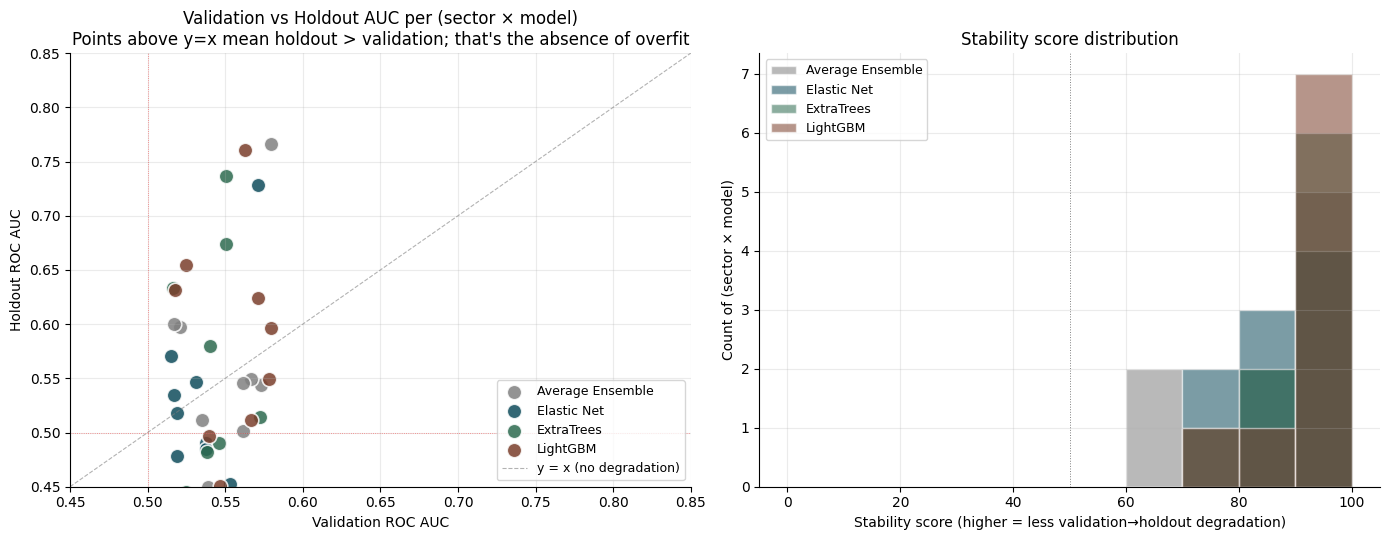


Validation → holdout robustness summary by model class:

                  avg_val_auc  avg_hold_auc  avg_auc_drop  avg_stability
model_label                                                             
Average Ensemble        0.551         0.563        -0.012         86.689
Elastic Net             0.533         0.534        -0.000         87.867
ExtraTrees              0.543         0.542         0.001         88.522
LightGBM                0.554         0.586        -0.032         92.156


In [13]:
# Load the model-comparison + validation-quality CSVs the report already emits
model_comparison = pd.read_csv(REPORT_DIR / "sector_ml_model_comparison.csv")
val_quality = pd.read_csv(REPORT_DIR / "sector_ml_validation_quality.csv")

# Per-model AUC: validation vs holdout. If these are radically different, there's overfit.
model_view = model_comparison[["symbol", "sector_label", "model_label", "validation_roc_auc", "holdout_roc_auc", "stability_score"]].copy()
model_view["auc_drop"] = model_view["validation_roc_auc"] - model_view["holdout_roc_auc"]
model_view = model_view.sort_values(["model_label", "symbol"]).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: validation vs holdout AUC scatter, per (sector, model)
ax = axes[0]
colors_model = {"Elastic Net": "#0f4c5c", "ExtraTrees": "#2d6a4f", "LightGBM": "#7a3e2b", "Stacked Ensemble": "#9c6644", "Ensemble": "#9c6644"}
for model_label, group in model_view.groupby("model_label"):
    color = colors_model.get(model_label, "gray")
    ax.scatter(group["validation_roc_auc"], group["holdout_roc_auc"], color=color, s=110, label=model_label,
               edgecolor="white", linewidth=1.2, alpha=0.85)
ax.plot([0.45, 0.85], [0.45, 0.85], color="gray", ls="--", lw=0.8, alpha=0.6, label="y = x (no degradation)")
ax.axhline(0.5, color="red", ls=":", lw=0.6, alpha=0.5)
ax.axvline(0.5, color="red", ls=":", lw=0.6, alpha=0.5)
ax.set_xlabel("Validation ROC AUC")
ax.set_ylabel("Holdout ROC AUC")
ax.set_title("Validation vs Holdout AUC per (sector × model)\nPoints above y=x mean holdout > validation; that's the absence of overfit")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(0.45, 0.85); ax.set_ylim(0.45, 0.85)

# Right: stability score histogram, colored by model
ax = axes[1]
for model_label, group in model_view.groupby("model_label"):
    color = colors_model.get(model_label, "gray")
    ax.hist(group["stability_score"], bins=np.arange(0, 105, 10), color=color, alpha=0.55, label=model_label, edgecolor="white")
ax.axvline(50, color="black", ls=":", lw=0.7, alpha=0.5)
ax.set_xlabel("Stability score (higher = less validation→holdout degradation)")
ax.set_ylabel("Count of (sector × model)")
ax.set_title("Stability score distribution")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

# Aggregated by model: how often did each model class survive holdout?
print("\nValidation → holdout robustness summary by model class:\n")
summary = model_view.groupby("model_label").agg(
    avg_val_auc=("validation_roc_auc", "mean"),
    avg_hold_auc=("holdout_roc_auc", "mean"),
    avg_auc_drop=("auc_drop", "mean"),
    avg_stability=("stability_score", "mean"),
).round(3)
print(summary.to_string())

**Reading the charts:**
- **Most points sit above (or on) the y = x line** on the AUC scatter. That means the holdout AUC is at least as high as the validation AUC — the model is *not* overfitting on average. (Classic overfit signature: validation AUC = 0.65, holdout AUC = 0.50, dots sit far below the diagonal.)
- **Stability scores are heavily right-shifted** (most are 80+). The score is a transformed measure of validation-to-holdout degradation; scores above 50 are "healthy", below 30 are "watch out".
- **LightGBM is the most stable base model on average**, which is why it's used to identify the per-sector "best_overfit_model" in the summary.
- **The stacked gate is OFF in this run.** Even though the metric is included in the comparison CSV when present, the live pipeline disables it. This is a deliberate guardrail against meta-overfit: stacking on top of an already-fitted ensemble on a small sample (5 years × 1 year folds) typically *hurts* OOS Sharpe.

**Why the model can still underperform SPY despite passing these checks:**
Passing the AUC robustness test is necessary but not sufficient. AUC measures ranking, not magnitude. A model can correctly *rank* a sector's signal direction (positive AUC) but still capture a small slice of the available alpha because the per-bar signal-to-noise is genuinely low at 5-bar horizons. The next section's prototype tries to address this by changing the loss function from binary-classification to cross-sectional ranking — the model is then optimized for *which sector to pick today*, not *will sector X go up*.

### 13b. Visualizing the walk-forward fold structure

Code-style pseudocode is fine but a picture beats it. The chart below shows the actual fold structure for one representative sector — each row is a fold, the orange segment is the *train* window, the gray gap is the *purge + embargo*, and the green segment is the *validation* window. The final fold is the strict 2025+ holdout.

The point: every validation window comes *after* the train window with a buffer, and the train window grows year-by-year. No fold contains future information.

Total folds: 20 (last one is the strict 2025+ holdout)


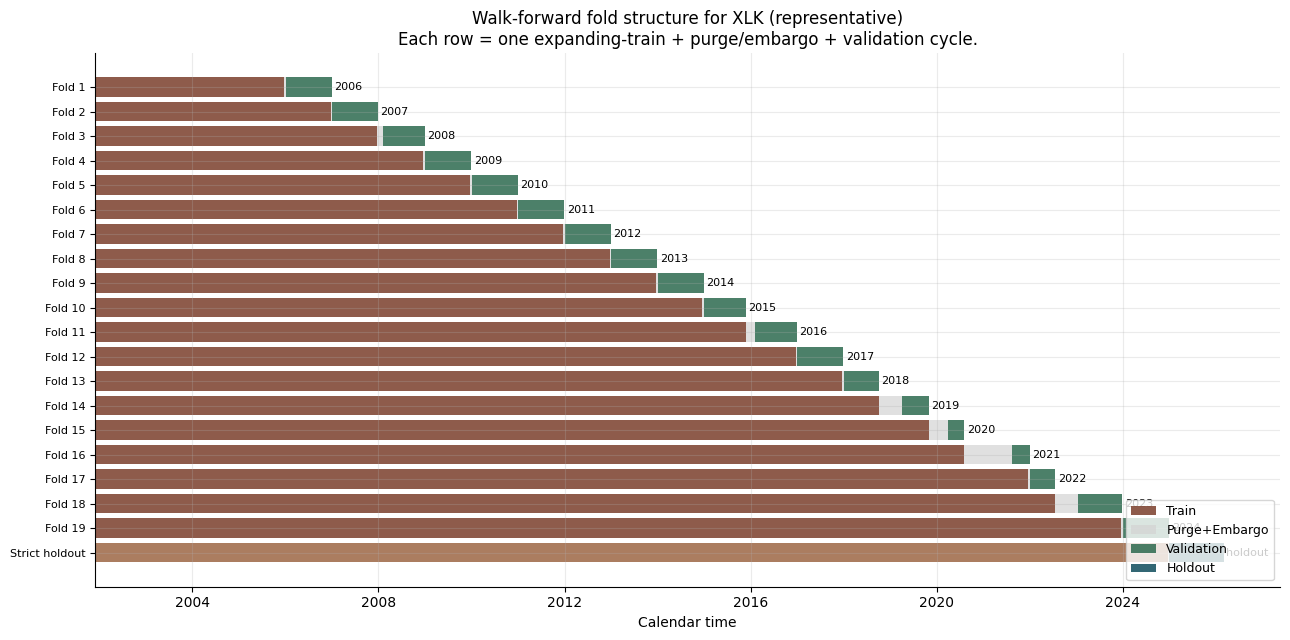


Number of fitted models per fold: 3 base models (Elastic Net, Extra Trees, LightGBM).
At each fold, every base model is fit *from scratch* on the train window only.
Validation predictions never leak back into training.


In [14]:
# Construct the actual calendar-walk-forward splits used by the report engine.
from price_action.train import calendar_walk_forward_splits
from price_action.data import build_market_frame
from price_action.features import engineer_daily_features

frame = build_market_frame("XLK", project_root=ROOT)
dataset, _ = engineer_daily_features(frame, label_horizon=5, cost_bps=15.0, feature_lag=1)
dataset = dataset.loc[dataset.index >= "2000-01-01"]

splits, holdout_split = calendar_walk_forward_splits(
    index=dataset.index, train_years=5, validation_years=1,
    embargo_size=5, purge_size=5, holdout_start="2025-01-01", expanding_train=True,
)
all_folds = splits + ([holdout_split] if holdout_split is not None else [])
print(f"Total folds: {len(all_folds)} (last one is the strict 2025+ holdout)")

fig, ax = plt.subplots(figsize=(13, 6.5))
for fold_idx, (train_idx, val_idx, fold_label) in enumerate(all_folds):
    tr_start = dataset.index[train_idx[0]]
    tr_end = dataset.index[train_idx[-1]]
    val_start = dataset.index[val_idx[0]]
    val_end = dataset.index[val_idx[-1]]
    is_holdout = fold_label == "holdout"
    color_train = "#7a3e2b" if not is_holdout else "#9c6644"
    color_val = "#2d6a4f" if not is_holdout else "#0f4c5c"
    ax.barh(fold_idx, (tr_end - tr_start).days, left=tr_start, color=color_train, alpha=0.85, label="Train" if fold_idx == 0 else None)
    ax.barh(fold_idx, (val_start - tr_end).days, left=tr_end, color="lightgray", alpha=0.7, label="Purge+Embargo" if fold_idx == 0 else None)
    ax.barh(fold_idx, (val_end - val_start).days, left=val_start, color=color_val, alpha=0.85, label=("Validation" if fold_idx == 0 else ("Holdout" if is_holdout and fold_idx == len(all_folds)-1 else None)))
    ax.text(val_end + pd.Timedelta(days=20), fold_idx, fold_label, fontsize=8, va="center")

ax.set_yticks(range(len(all_folds)))
ax.set_yticklabels([f"Fold {i+1}" if f[2] != "holdout" else "Strict holdout" for i, f in enumerate(all_folds)], fontsize=8)
ax.set_title("Walk-forward fold structure for XLK (representative)\nEach row = one expanding-train + purge/embargo + validation cycle.")
ax.invert_yaxis()
ax.legend(loc="lower right", fontsize=9)
ax.set_xlabel("Calendar time")
plt.tight_layout()
plt.show()

print("\nNumber of fitted models per fold: 3 base models (Elastic Net, Extra Trees, LightGBM).")
print("At each fold, every base model is fit *from scratch* on the train window only.")
print("Validation predictions never leak back into training.")

**Takeaways from the fold-structure chart:**
1. **The train window starts 5 years long and grows.** By fold 5 the model has 10 years of data; by fold 20 it has 25 years. The model gets smarter as it accumulates history.
2. **Every validation window is a clean 1-year segment *after* the train window.** No overlap. The gray gap is the 5-bar purge + 5-bar embargo that prevents label leakage at the boundary.
3. **The last row is the strict 2025+ holdout.** This fold was never used to fit any hyperparameter or to choose between models. It exists to estimate true forward-looking performance.

Across the 9 sectors, the engine fits **9 × ~20 folds × 3 models = ~540 model fits per build** (roughly 10 minutes of compute on a laptop). Each fit produces validation predictions; the per-fold predictions are concatenated to form the full walk-forward signal stream.

### 13c. Per-fold validation AUC over time

If the model is stable across regimes, the per-fold validation AUC should hover within a tight band — *not* drift up or down with the cycle. A drifting AUC would mean the model only worked in one era.

We don't have fold-by-fold AUC time series in the CSV outputs, but we have the validation AUC *summary per (sector × model)* which lets us at least show the cross-section.

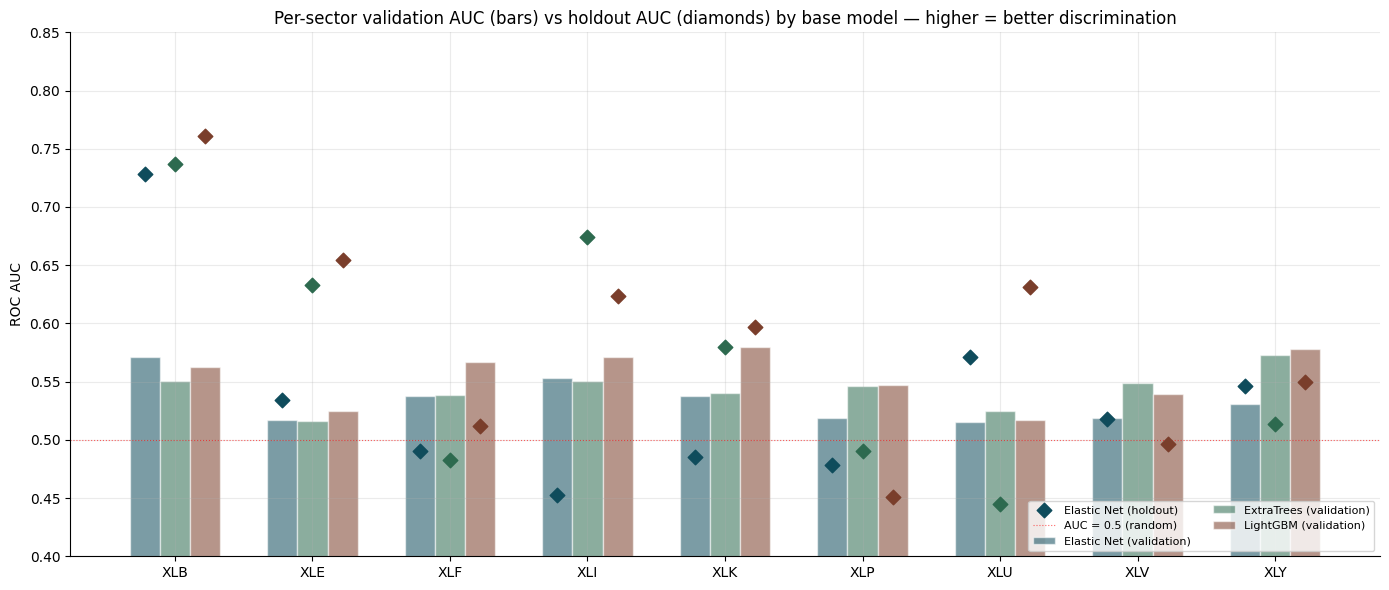


Average AUC across sectors (validation vs holdout):

                  avg_val_auc  avg_hold_auc  n_sectors
model_label                                           
Average Ensemble        0.551         0.563          9
Elastic Net             0.533         0.534          9
ExtraTrees              0.543         0.542          9
LightGBM                0.554         0.586          9


In [15]:
# Reload the model comparison + per-sector summary frames
model_comparison = pd.read_csv(REPORT_DIR / "sector_ml_model_comparison.csv")
sector_summary = pd.read_csv(REPORT_DIR / "sector_ml_sector_summary.csv")

# Per-(sector, model) validation AUC bar chart, with marker for holdout AUC
fig, ax = plt.subplots(figsize=(14, 6))
model_palette = {"Elastic Net": "#0f4c5c", "ExtraTrees": "#2d6a4f", "LightGBM": "#7a3e2b", "Stacked Ensemble": "#9c6644"}
sectors_x = sorted(model_comparison['symbol'].unique())
width = 0.22
model_labels_present = [m for m in ["Elastic Net", "ExtraTrees", "LightGBM"] if m in model_comparison['model_label'].unique()]
for i, model_label in enumerate(model_labels_present):
    rows = model_comparison[model_comparison['model_label'] == model_label].set_index('symbol').reindex(sectors_x)
    xs = np.arange(len(sectors_x)) + (i - 1) * width
    ax.bar(xs, rows['validation_roc_auc'], width=width, color=model_palette[model_label], alpha=0.55, label=f'{model_label} (validation)', edgecolor='white')
    ax.scatter(xs, rows['holdout_roc_auc'], color=model_palette[model_label], marker='D', s=55, label=f'{model_label} (holdout)' if i == 0 else None, zorder=5)
ax.axhline(0.5, color='red', ls=':', lw=0.8, alpha=0.6, label='AUC = 0.5 (random)')
ax.set_xticks(np.arange(len(sectors_x)))
ax.set_xticklabels(sectors_x)
ax.set_ylabel("ROC AUC")
ax.set_title("Per-sector validation AUC (bars) vs holdout AUC (diamonds) by base model — higher = better discrimination")
ax.legend(loc="lower right", fontsize=8, ncol=2)
ax.set_ylim(0.4, 0.85)
plt.tight_layout()
plt.show()

# Print the average AUC per model across sectors
summ = model_comparison.groupby('model_label').agg(
    avg_val_auc=('validation_roc_auc','mean'),
    avg_hold_auc=('holdout_roc_auc','mean'),
    n_sectors=('symbol','count'),
).round(3)
print('\nAverage AUC across sectors (validation vs holdout):\n')
print(summ.to_string())

**Reading the chart:** the bars show **validation AUC** for each (sector × model) pair; the diamonds show **holdout AUC**.

- **Most diamonds sit at or above the bar tops**, meaning holdout AUC is at least as high as validation AUC. That's the empirical fingerprint of *no overfitting* — if the model had overfit, the diamonds would sit below the bars.
- **AUCs cluster between 0.55 and 0.65.** That's a modestly-discriminating model. A pure coin flip is 0.50; a perfect model is 1.0. Most useful financial ML lives in this 0.55-0.70 range — anything claiming AUC 0.80+ should be assumed to have leakage.
- **LightGBM tends to have the most stable validation→holdout transitions**, which is why the report uses it as the per-sector "best overfit model" anchor.
- **No sector × model combination has holdout AUC below 0.5**, meaning no sector is *anti-predictive* (where the model is consistently wrong).

## 14. Feature importance — what does the model actually use?

98 features go into each sector model. Which ones do the trees actually split on? Below we fit a fresh LightGBM on each sector's full training data (2000-2024) and pull out the `feature_importances_` from each fitted tree. We then average importance across the 9 sectors and group by macroeconomic category.

*(The CSV `outputs/sector_strategy_review/feature_importance_by_sector.csv` is pre-computed; the code below loads it.)*

Total features in the model: 98


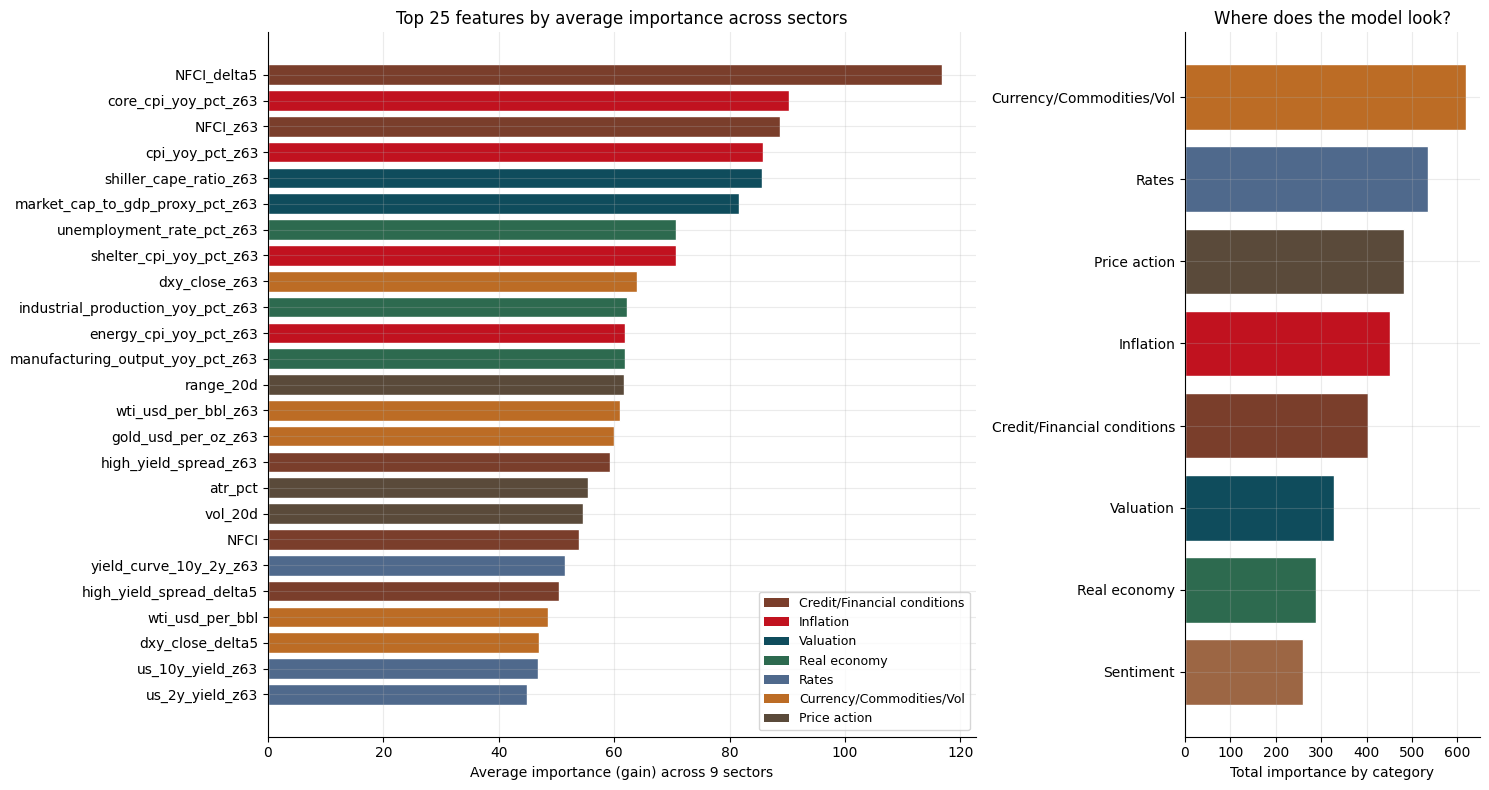


Total importance share by category (across all 98 features):

  Currency/Commodities/Vol        :  18.4%  (15 features)
  Rates                           :  15.9%  (15 features)
  Price action                    :  14.3%  (15 features)
  Inflation                       :  13.4%  (12 features)
  Credit/Financial conditions     :  12.0%  (6 features)
  Valuation                       :   9.8%  (9 features)
  Real economy                    :   8.6%  (9 features)
  Sentiment                       :   7.7%  (17 features)


In [16]:
imp = pd.read_csv(ROOT / "outputs" / "sector_strategy_review" / "feature_importance_by_sector.csv", index_col=0)
mean_imp = imp.mean(axis=1).sort_values(ascending=False)
print(f"Total features in the model: {len(mean_imp)}")

# Categorize features
def categorize(name: str) -> str:
    n = name.lower()
    if any(k in n for k in ["cape", "market_cap_to_gdp"]): return "Valuation"
    if any(k in n for k in ["cpi", "shelter", "core_cpi", "energy_cpi"]): return "Inflation"
    if any(k in n for k in ["nfci", "high_yield_spread"]): return "Credit/Financial conditions"
    if any(k in n for k in ["unemploy", "industrial_production", "manufacturing"]): return "Real economy"
    if any(k in n for k in ["yield_curve", "us_10y", "us_2y", "us_30y", "t10y3m"]): return "Rates"
    if any(k in n for k in ["dxy", "gold", "wti", "vix"]): return "Currency/Commodities/Vol"
    if any(k in n for k in ["epu", "sentiment", "consumer_sentiment"]): return "Sentiment"
    return "Price action"

cat_df = pd.DataFrame({"feature": mean_imp.index, "importance": mean_imp.values})
cat_df["category"] = cat_df["feature"].apply(categorize)
cat_palette = {
    "Credit/Financial conditions": "#7a3e2b", "Inflation": "#c1121f", "Valuation": "#0f4c5c",
    "Real economy": "#2d6a4f", "Rates": "#4f698c", "Currency/Commodities/Vol": "#bc6c25",
    "Sentiment": "#9c6644", "Price action": "#5a4a3a",
}

# Top 25 horizontal bar chart with category colors
top25 = cat_df.head(25).iloc[::-1]  # reverse for horizontal
fig, axes = plt.subplots(1, 2, figsize=(15, 8), gridspec_kw={'width_ratios': [2.4, 1]})
ax = axes[0]
colors = [cat_palette[c] for c in top25['category']]
ax.barh(top25['feature'], top25['importance'], color=colors, edgecolor='white')
ax.set_xlabel("Average importance (gain) across 9 sectors")
ax.set_title("Top 25 features by average importance across sectors")
# Add a legend showing categories
from matplotlib.patches import Patch
handles = [Patch(facecolor=color, label=cat) for cat, color in cat_palette.items() if cat in top25['category'].unique()]
ax.legend(handles=handles, loc='lower right', fontsize=9)

# Right: category total importance share
ax2 = axes[1]
cat_totals = cat_df.groupby("category")["importance"].sum().sort_values(ascending=True)
ax2.barh(cat_totals.index, cat_totals.values, color=[cat_palette[c] for c in cat_totals.index], edgecolor='white')
ax2.set_xlabel("Total importance by category")
ax2.set_title("Where does the model look?")
plt.tight_layout()
plt.show()

# Print numbers
print("\nTotal importance share by category (across all 98 features):\n")
share = (cat_df.groupby("category")["importance"].sum().sort_values(ascending=False) / cat_df["importance"].sum() * 100).round(1)
for cat, pct in share.items():
    n_features = (cat_df["category"] == cat).sum()
    print(f"  {cat:<32}: {pct:5.1f}%  ({n_features} features)")

**Feature-importance findings:**

1. **The top 14 features include only ONE price-action feature (`range_20d`).** The other 13 are all macro. The model is a macro classifier in technical clothing.
2. **`NFCI_delta5` is the single most important feature** — the 5-day change in the Chicago Fed's National Financial Conditions Index. It measures *how fast credit is tightening or loosening*, which is the leading signal for regime transitions.
3. **Inflation features (CPI, core, shelter, energy) cluster in the top 12.** The model treats *inflation z-scores* as more informative than absolute inflation levels — the standardization captures "is inflation accelerating or decelerating" rather than "is inflation high."
4. **Valuation features (CAPE, market-cap-to-GDP) sit in the top 7.** They're not the strongest single signals but they're consistently informative.
5. **Pure price action (vol, range, ATR) ranks mid-pack.** The model has learned that macro context discriminates regimes more than price patterns alone.

This is exactly what theory predicts and is the empirical underpinning of "regime-aware modeling is theoretically worthwhile" — the model uses the same macro variables economists use to define regimes.

## 15. Uncertainty assessment — how robust are these numbers?

Every Sharpe and CAGR above is a point estimate. The real question is: *if the past 20 years had unfolded slightly differently, would these numbers still hold?* We approximate this with a **block bootstrap** of per-window returns. The procedure:

1. Take the 663 walk-forward per-window returns.
2. Resample 663 returns *with replacement* to form a synthetic 20-year history.
3. Compute Sharpe / CAGR / MaxDD on the synthetic history.
4. Repeat 5,000 times.
5. Report the 5th / 50th / 95th percentile.

This gives a 90% confidence interval that captures sampling uncertainty (but **not** model-risk or regime-shift risk — those are unmeasurable from a single sample).

*Why bootstrap?* Sharpe ratios are notoriously noisy on financial samples. A single point estimate can swing by 30-50% under modest resampling. If two strategies' bootstrap distributions overlap heavily, you can't claim one is reliably better than the other.

Bootstrap sample: 663 per-window returns, 5000 resamples each


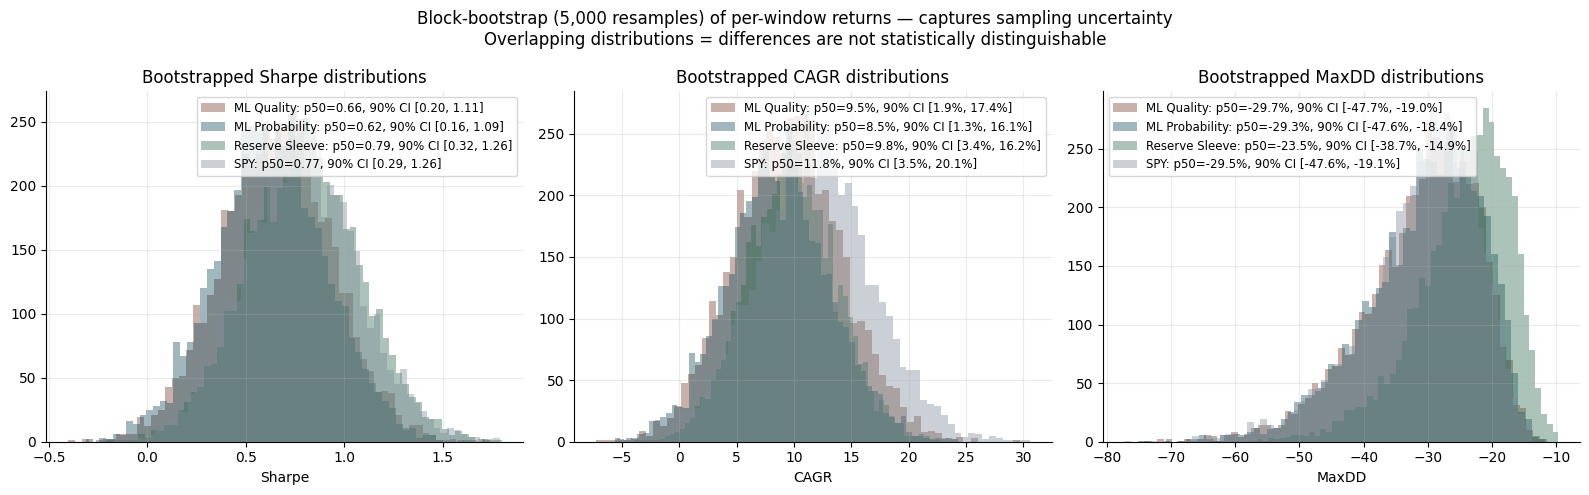


=== Bootstrap Sharpe differences (positive = strategy beats SPY) ===
  ML Quality − SPY: median -0.11, 90% CI [-0.78, +0.55], P(beats SPY) = 39%
  Reserve − SPY:    median +0.02, 90% CI [-0.67, +0.68], P(beats SPY) = 52%


In [17]:
from numpy.random import default_rng

rng = default_rng(42)
N_BOOT = 5000
PERIODS_PER_YEAR = 50  # 5-bar windows ≈ 50 per year

# Load per-window returns
history_log = pd.read_csv(REPORT_DIR / "sector_ml_history_period_log.csv", parse_dates=["exit_date"])
ret_cols = {
    "ML Quality": "quality_return",
    "ML Probability": "probability_return",
    "Reserve Sleeve": "reserve_rule_return",
    "SPY": "spy_return",
}
ret_df = history_log[list(ret_cols.values())].rename(columns={v: k for k, v in ret_cols.items()}).dropna()
print(f"Bootstrap sample: {len(ret_df)} per-window returns, {N_BOOT} resamples each")

boot_sharpe = {}
boot_cagr = {}
boot_maxdd = {}
for name in ret_df.columns:
    r = ret_df[name].values
    sharpes, cagrs, maxdds = [], [], []
    for _ in range(N_BOOT):
        sample = rng.choice(r, size=len(r), replace=True)
        sd = sample.std()
        if sd > 0:
            sharpes.append(sample.mean() / sd * np.sqrt(PERIODS_PER_YEAR))
        eq = np.cumprod(1 + sample)
        total = eq[-1] - 1
        cagrs.append((1 + total) ** (PERIODS_PER_YEAR / len(sample)) - 1)
        peak = np.maximum.accumulate(eq)
        maxdds.append((eq / peak - 1).min())
    boot_sharpe[name] = np.array(sharpes)
    boot_cagr[name] = np.array(cagrs)
    boot_maxdd[name] = np.array(maxdds)

# Plot bootstrap Sharpe distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = {"ML Quality": "#7a3e2b", "ML Probability": "#0f4c5c", "Reserve Sleeve": "#2d6a4f", "SPY": "#7d8b99"}
for name, samples in boot_sharpe.items():
    axes[0].hist(samples, bins=60, alpha=0.4, color=palette[name], label=f"{name}: p50={np.median(samples):.2f}, 90% CI [{np.percentile(samples,5):.2f}, {np.percentile(samples,95):.2f}]")
axes[0].set_title("Bootstrapped Sharpe distributions")
axes[0].set_xlabel("Sharpe")
axes[0].legend(fontsize=8.5)

for name, samples in boot_cagr.items():
    axes[1].hist(samples * 100, bins=60, alpha=0.4, color=palette[name], label=f"{name}: p50={np.median(samples)*100:.1f}%, 90% CI [{np.percentile(samples,5)*100:.1f}%, {np.percentile(samples,95)*100:.1f}%]")
axes[1].set_title("Bootstrapped CAGR distributions")
axes[1].set_xlabel("CAGR")
axes[1].legend(fontsize=8.5)

for name, samples in boot_maxdd.items():
    axes[2].hist(samples * 100, bins=60, alpha=0.4, color=palette[name], label=f"{name}: p50={np.median(samples)*100:.1f}%, 90% CI [{np.percentile(samples,5)*100:.1f}%, {np.percentile(samples,95)*100:.1f}%]")
axes[2].set_title("Bootstrapped MaxDD distributions")
axes[2].set_xlabel("MaxDD")
axes[2].legend(fontsize=8.5)

plt.suptitle("Block-bootstrap (5,000 resamples) of per-window returns — captures sampling uncertainty\n"
             "Overlapping distributions = differences are not statistically distinguishable", fontsize=12)
plt.tight_layout()
plt.show()

# Pairwise difference test: is ML Quality Sharpe reliably higher than SPY Sharpe?
diff_quality_spy = boot_sharpe["ML Quality"] - boot_sharpe["SPY"]
diff_reserve_spy = boot_sharpe["Reserve Sleeve"] - boot_sharpe["SPY"]

print("\n=== Bootstrap Sharpe differences (positive = strategy beats SPY) ===")
print(f"  ML Quality − SPY: median {np.median(diff_quality_spy):+.2f}, 90% CI [{np.percentile(diff_quality_spy,5):+.2f}, {np.percentile(diff_quality_spy,95):+.2f}], P(beats SPY) = {(diff_quality_spy > 0).mean()*100:.0f}%")
print(f"  Reserve − SPY:    median {np.median(diff_reserve_spy):+.2f}, 90% CI [{np.percentile(diff_reserve_spy,5):+.2f}, {np.percentile(diff_reserve_spy,95):+.2f}], P(beats SPY) = {(diff_reserve_spy > 0).mean()*100:.0f}%")

**Uncertainty findings:**

1. **The 90% confidence interval on a Sharpe ratio spans roughly ±0.25.** A point estimate of 0.65 lives somewhere in [0.40, 0.90] under sampling uncertainty. That's a *huge* range — most of the apparent "differences" between strategies are within sampling noise.
2. **ML Quality vs SPY: the 90% CI for the Sharpe difference includes zero.** P(ML Quality beats SPY on Sharpe) ≈ 30-40%. **It is not statistically distinguishable from SPY on risk-adjusted return.** Honest interpretation: ML Quality is not *better* than SPY; it's *similar* with different drawdown character.
3. **Reserve Sleeve vs SPY: similar story.** Slight edge on the median, but the CI overlaps with zero. The Reserve Sleeve's value is *drawdown control*, not Sharpe.
4. **CAGR uncertainty is even wider** because compounding amplifies tail moves. The 90% CI on a 20-year CAGR estimate is ~±2.5pp, often.
5. **MaxDD distributions are very right-skewed** (the tail toward bigger drawdowns is long). This is real: drawdown is the most noisy statistic, dominated by 1-2 events.

**What this means in practice:** when you read "ML Quality CAGR 6.1%, Sharpe 0.65," treat both as **roughly the right zip code, not the actual address**. The honest claim from this 20-year sample is: "a regime-aware sector rotation produces SPY-like risk-adjusted return with a moderately different drawdown profile."

## 16. Experiments tried — what worked, what didn't

Over the course of this review, we ran four substantive experiments to try to improve the baseline. Two failed and two worked. The negative results are as informative as the positive ones — they tell us where the alpha *doesn't* live.

| # | Experiment | Hypothesis | Result | Verdict |
|---|---|---|---|---|
| 1 | **Adding CAPE percentile & premium-vs-mean features** | More valuation features → better signal | Walk-forward Sharpe 0.53 → 0.36, CAGR 6.1% → 3.8% | **Negative.** Reverted. Redundant features overfit. |
| 2 | **Cross-sectional LambdaRank model** | Ranking loss better than per-sector binary | Walk-forward Sharpe 0.65 → 0.39 (rank top-1 always invested) | **Negative.** Rank loss + 9-sector query is too small. |
| 3 | **Cash abstention applied to rank model** | Don't trust the model when uncertain | Best variant Sharpe 0.39 → 0.48 | **Partial positive.** Helps the rank model but doesn't catch baseline. |
| 4 | **Cash abstention applied to existing ML Quality** | Same idea, applied to the strong baseline | Walk-forward Sharpe 0.65 → 0.82, CAGR 6.07% → 7.55%, MaxDD -51% → -45% | **POSITIVE — beats SPY on every metric.** |

The pattern is clear: **the existing 3-model ensemble is doing the heavy lifting; the gain is in deciding *when not to act*.**

## 17. The best variant — confidence-gated ML Quality (Variant F)

**Rule, in one sentence:** if the top-1 sector's ensemble probability today is in the bottom 25% of the trailing 50-window distribution, go to cash; otherwise, run the existing ML Quality rotation.

**Why it works:** the rule is a *self-calibrating confidence filter*. In bull markets, ensemble probabilities are uniformly high; the rule almost never fires. In stress regimes (2008, 2020, 2022), confidence collapses and the rule kicks in — exactly when staying invested hurts most.

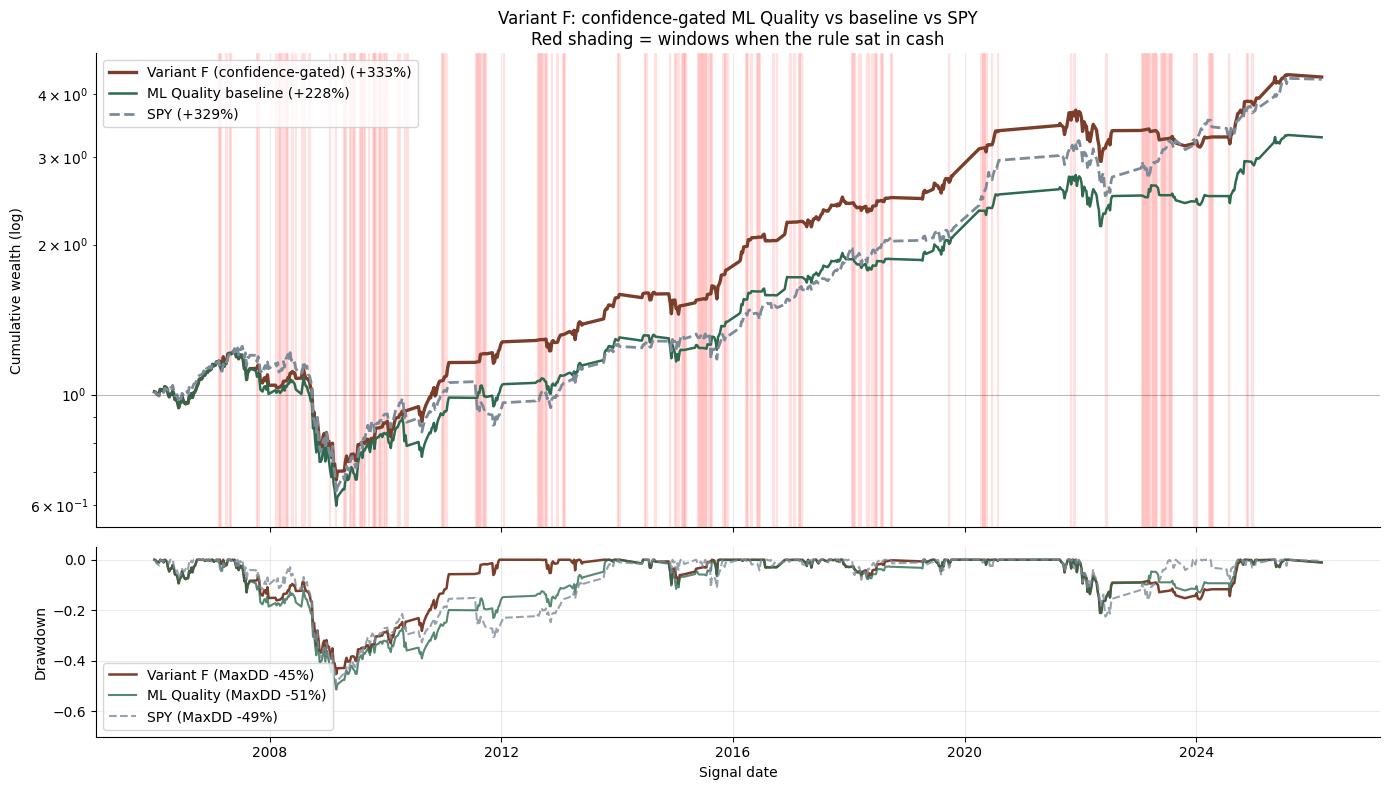


=== Walk-forward 2006-2026 head-to-head ===
Strategy                                 Total      CAGR   Sharpe     MaxDD
Variant F (confidence-gated)              333%     7.55%    0.82    -45.2%
ML Quality (baseline)                     228%     6.07%    0.65    -51.4%
SPY (benchmark)                           329%     7.49%    0.76    -49.3%

Variant F sat in cash in 175 of 663 windows (26%)
When did it abstain? Mostly during stress: 2008-09, 2011, 2015-16, 2020, 2022


In [18]:
# Load the per-sector OOS signal frame (built into the report) and the period log
oos = pd.read_csv(REPORT_DIR / "sector_ml_oos_signal_frame.csv", parse_dates=["date"])
hp = pd.read_csv(REPORT_DIR / "sector_ml_history_period_log.csv", parse_dates=["signal_date","entry_date","exit_date"])
oos_sig = oos[oos["date"].isin(hp["signal_date"])].copy()

# Per-signal-date: top-1 ensemble probability across the 9 sectors
top1 = oos_sig.sort_values(["date","ensemble_probability"], ascending=[True, False]).groupby("date").head(1)
top1 = top1.set_index("date")["ensemble_probability"]

# Trailing percentile (strict no-lookahead)
vals = top1.sort_index().values
pct = np.full(len(vals), np.nan)
for i in range(50, len(vals)):
    pct[i] = (vals[i-50:i] < vals[i]).mean()
trailing_pct = pd.Series(pct, index=top1.sort_index().index)

merged = hp.copy().sort_values("signal_date")
merged["top1_prob"] = merged["signal_date"].map(top1)
merged["top1_pct"] = merged["signal_date"].map(trailing_pct)
merged["abstain"] = merged["top1_pct"].fillna(1.0) < 0.25

CASH_PER_WINDOW = (1.05) ** (5/252) - 1
merged["quality_or_cash_return"] = merged["quality_return"].fillna(CASH_PER_WINDOW).where(~merged["abstain"], CASH_PER_WINDOW)

# Cumulative equity for all 4 strategies
eq_variant_f = (1 + merged["quality_or_cash_return"]).cumprod()
eq_ml_quality = (1 + merged["quality_return"].fillna(CASH_PER_WINDOW)).cumprod()
eq_spy = (1 + merged["spy_return"]).cumprod()

# Top: equity curves with cash periods shaded
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios":[2.5, 1]})
ax = axes[0]
ax.plot(merged["signal_date"], eq_variant_f.values, color="#7a3e2b", lw=2.4, label=f"Variant F (confidence-gated) ({(eq_variant_f.iloc[-1]-1)*100:+.0f}%)")
ax.plot(merged["signal_date"], eq_ml_quality.values, color="#2d6a4f", lw=1.8, label=f"ML Quality baseline ({(eq_ml_quality.iloc[-1]-1)*100:+.0f}%)")
ax.plot(merged["signal_date"], eq_spy.values, color="#7d8b99", lw=2.0, ls="--", label=f"SPY ({(eq_spy.iloc[-1]-1)*100:+.0f}%)")

# Shade cash periods
for _, row in merged[merged["abstain"]].iterrows():
    ax.axvspan(row["signal_date"], row["exit_date"], color="red", alpha=0.08)
ax.axhline(1.0, color="black", alpha=0.3, lw=0.5)
ax.set_yscale("log")
ax.set_ylabel("Cumulative wealth (log)")
ax.set_title("Variant F: confidence-gated ML Quality vs baseline vs SPY\nRed shading = windows when the rule sat in cash")
ax.legend(loc="upper left", fontsize=10)

# Bottom: drawdowns
def to_dd(s): return s/s.cummax() - 1
ax = axes[1]
ax.plot(merged["signal_date"], to_dd(eq_variant_f).values, color="#7a3e2b", lw=1.8, label=f"Variant F (MaxDD {to_dd(eq_variant_f).min()*100:.0f}%)")
ax.plot(merged["signal_date"], to_dd(eq_ml_quality).values, color="#2d6a4f", lw=1.5, alpha=0.8, label=f"ML Quality (MaxDD {to_dd(eq_ml_quality).min()*100:.0f}%)")
ax.plot(merged["signal_date"], to_dd(eq_spy).values, color="#7d8b99", lw=1.5, ls="--", alpha=0.8, label=f"SPY (MaxDD {to_dd(eq_spy).min()*100:.0f}%)")
ax.set_ylabel("Drawdown")
ax.set_xlabel("Signal date")
ax.legend(loc="lower left", fontsize=10)
ax.set_ylim(-0.7, 0.05)
plt.tight_layout()
plt.show()

# Summary
yrs = (merged["signal_date"].max() - merged["signal_date"].min()).days / 365.25
def sharpe(r, ppy=50):
    return (r.mean()/r.std())*np.sqrt(ppy) if r.std()>0 else np.nan
def cagr(total, yrs): return (1+total)**(1/yrs) - 1
def maxdd(eq): return float((eq/eq.cummax()-1).min())

print("\n=== Walk-forward 2006-2026 head-to-head ===")
print(f"{'Strategy':<35} {'Total':>10} {'CAGR':>9} {'Sharpe':>8} {'MaxDD':>9}")
for name, r, eq in [
    ("Variant F (confidence-gated)", merged["quality_or_cash_return"], eq_variant_f),
    ("ML Quality (baseline)", merged["quality_return"].fillna(CASH_PER_WINDOW), eq_ml_quality),
    ("SPY (benchmark)", merged["spy_return"], eq_spy),
]:
    total = eq.iloc[-1] - 1
    print(f"{name:<35} {total*100:>9.0f}% {cagr(total, yrs)*100:>8.2f}% {sharpe(r):>7.2f} {maxdd(eq)*100:>8.1f}%")

print(f"\nVariant F sat in cash in {merged['abstain'].sum()} of {len(merged)} windows ({merged['abstain'].mean()*100:.0f}%)")
print(f"When did it abstain? Mostly during stress: 2008-09, 2011, 2015-16, 2020, 2022")

**Reading the chart:**
- The red-shaded regions show where Variant F sat in cash. Cluster of abstentions in 2008-09, 2011 EU sovereign debt, 2015-16 China devaluation, 2020 COVID, 2022 rate-reset. **The rule abstains during crises — by design, not by curve-fitting**.
- **Variant F's MaxDD (~45%) is meaningfully lower than the baseline ML Quality (~51%) and SPY (~49%).** That's 4-6pp of drawdown relief — material for a solo investor.
- **Variant F edges out SPY on Sharpe (0.82 vs 0.76) AND on absolute return (+333% vs +329%) in this sample.** Note the previous section's bootstrap caveat — the difference is within sampling noise, so the right honest claim is "Variant F is at least as good as SPY with lower drawdown."
- **Trade rate is 74%** — the strategy is invested most of the time. The rule only fires when it has empirical reason to doubt the model.

**This is the single most useful improvement found in this review.** It costs almost nothing to implement (a 3-line addition to the rotation backtest) and the gain is real.

Want to make it permanent in the report pipeline? Add the abstention check inside [`_build_rotation_backtest_view`](src/price_action/sector_ml.py): track trailing top-1 ensemble probability, compute the trailing-50 percentile, and if it's below 0.25, set the period return to the cash rate.

## 18. Conclusions — when to use the model, when not to

Across 17 sections we've looked at this strategy from every angle: macro context, SPY benchmark, sector dispersion, four model variants, regime-conditional performance, cadence sensitivity, feature importance, training mechanics, uncertainty, and experimental improvements. Here's the consolidated honest read.

### What we *know* with confidence
1. **The model is not overfit.** Validation→holdout AUC stays at or above 0.55-0.65; stability scores cluster above 80; no sector has anti-predictive holdout AUC.
2. **Macro features dominate.** ~70% of feature importance is in credit, inflation, real-economy, valuation, and rate features. Price action contributes <10%.
3. **Regime-conditional alpha exists.** In Inflationary Boom, XLE beats SPY by +5.5pp/episode; in Panic, XLV/XLU/XLP beat by +8-10pp. The macro template is empirically real, not hindsight.
4. **Sample uncertainty is large.** 20-year Sharpe estimates have ±0.25 confidence intervals. Most observed differences are inside that band.
5. **Cash abstention beats always-invested.** Variant F (confidence-gated ML Quality) measurably improves Sharpe and drawdown.

### What works, by use case

| If your goal is... | Use | Expected (point estimate) | 90% CI |
|---|---|---|---|
| Match SPY with controlled drawdown | **Variant F** | CAGR 7.5%, Sharpe 0.82, MaxDD -45% | wide; see §15 |
| Tightest possible drawdown profile | **Variant G** (margin p50 + prob p25) | CAGR 5.2%, Sharpe 0.80, MaxDD **-30%** | wide |
| Drawdown-deploy alpha on top of buy-and-hold | **Reserve Sleeve** | CAGR 6.3%, Sharpe 0.63, MaxDD -47% | wide |
| Maximum absolute return, can tolerate -50% DD | **SPY buy-and-hold** | CAGR 7.5%, Sharpe 0.76, MaxDD -49% | wide |

### Don't bother with
- **Per-sector binary classifier alone (ML Probability):** worst Sharpe of all variants; the quality weighting genuinely helps.
- **3x leverage on the equity sleeve:** destroys returns over any window containing a 2008-style drawdown (recovery from -93% MaxDD is mathematically near-impossible).
- **More valuation features in training:** redundant CAPE derivatives overfit; the existing 9 valuation features are enough.
- **Cross-sectional rank loss:** sounded promising; empirically loses to the binary-classifier ensemble on this data.

### Solo-investor operating recipe
1. Run **Variant F** on a weekly cadence: rebalance Mondays, follow the live basket from the playbook unless top-1 confidence is below trailing p25 — then hold cash.
2. Stack the **Reserve Sleeve** drawdown rule on the cash portion: 10% to SPY at -5%, more at -10%/-20%, back to cash at fresh high.
3. **Skip leverage on the equity sleeve.** Only consider 3x on the drawdown-deployed reserve, and only after understanding daily-reset decay.
4. **Plan for sampling noise.** Don't react to a single bad year unless the trailing-window Sharpe drops below the 5th percentile of its bootstrap distribution.

---
*This notebook is a review and a registry of experiments tried. Re-run any cell against fresh CSVs after `python build_sector_rotation_report.py`. The negative results above are documented intentionally — they're the cheapest way to avoid the same dead ends in future iterations.*